# Анализ результатов A/B-теста новой рекомендательной модели

## 1. Проверка качества данных
Анализ имеющихся данных,что нужно проверить:
| Проблема | Таблица для проверки | Что считаем нарушением / риском |
|---|---|---|
| Пользователь назначен в обе экспериментальные группы | `experiment_assignments.csv` | Один `user_id` имеет назначения и в Control, и в Test. Это нарушает чистоту сравнения групп. `assignment_source` поможет понять возможную причину. |
| Bot-like пользователи с необычно высокой активностью | `users.csv`, затем связанные `clicks.csv` и `impressions.csv` | `is_bot_candidate = 1` — не автоматическая ошибка, а кандидат на отдельную проверку и возможное исключение. Нужно оценить влияние на метрики и распределение между группами. |
| Пропущенная стоимость доставки | `orders.csv` | `delivery_fee_rub` имеет пропуск (`NULL` / пустое значение). Значение `0` само по себе не считаем ошибкой. |
| Дублирующиеся события показа | `impressions.csv` | `is_duplicate_event = 1`. Нужно определить, не исказят ли эти строки число показов и производные метрики. |
| Возвраты после окна наблюдения | `orders.csv` | У возвращённого заказа `return_date` находится позже окончания 30-дневного окна эксперимента. Это риск некорректного учёта возвратов в результатах теста. |

* Сначала конфликтующие назначения (уровень 1) — без этого сравнение групп нечестно
* Потом боты (уровень 1) — их поведение не репрезентативно
* Потом дубли показов (уровень 2) — искажают CTR
* Потом пропуски delivery_fee (уровень 2) — искажают метрики стоимости доставки
* В конце поздние возвраты (уровень 2) — искажают return rate

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Настройки визуализации
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)

# Путь к данным
DATA_DIR = Path('../data/raw/soa_hackathon_2026_marketplace_dataset')

# Загружаем все таблицы сразу
users = pd.read_csv(DATA_DIR / 'users.csv')
assignments = pd.read_csv(DATA_DIR / 'experiment_assignments.csv')
sessions = pd.read_csv(DATA_DIR / 'sessions.csv')
impressions = pd.read_csv(DATA_DIR / 'impressions.csv')
clicks = pd.read_csv(DATA_DIR / 'clicks.csv')
orders = pd.read_csv(DATA_DIR / 'orders.csv')
products = pd.read_csv(DATA_DIR / 'products.csv')
sellers = pd.read_csv(DATA_DIR / 'sellers.csv')
support = pd.read_csv(DATA_DIR / 'support_tickets.csv')
premium = pd.read_csv(DATA_DIR / 'premium_subscriptions.csv')

print('Загружено таблиц: 10')
for name, df in [('users', users), ('assignments', assignments),
                 ('sessions', sessions), ('impressions', impressions),
                 ('clicks', clicks), ('orders', orders)]:
    print(f'{name:15} {df.shape[0]:>8} строк, {df.shape[1]:>2} колонок')

Загружено таблиц: 10
users              50000 строк,  8 колонок
assignments        50300 строк,  6 колонок
sessions          164739 строк,  9 колонок
impressions      1066434 строк,  9 колонок
clicks             91266 строк,  7 колонок
orders              7407 строк, 14 колонок


In [2]:
# Группируем по user_id и считаем два агрегата
user_stats = assignments.groupby('user_id').agg(
    assignment_count=('assignment_id', 'count'),      # COUNT(*)
    group_count=('experiment_group', 'nunique')       # COUNT(DISTINCT ...)
).reset_index()

# Оставляем только пользователей с повторными назначениями
conflicted_users = user_stats[user_stats['assignment_count'] > 1]

# Итоговая статистика
print(f'Всего пользователей: {len(user_stats)}')
print(f'С повторными назначениями: {len(conflicted_users)}')
print(f'Из них в обеих группах: {len(conflicted_users[conflicted_users["group_count"] > 1])}')

Всего пользователей: 50000
С повторными назначениями: 300
Из них в обеих группах: 300


### 1.1 Конфликтующие назначения в экспериментальные группы

**Что проверяем:** пользователи, которые оказались одновременно в Control и Test.

**Почему это важно:** если пользователь находится в обеих группах, мы не можем честно атрибутировать его действия (клики, заказы) к конкретной версии алгоритма. Это нарушает чистоту сравнения.

**Как проверяем:** группируем `experiment_assignments` по `user_id`, считаем число разных `experiment_group`, оставляем пользователей с `group_count > 1`.

In [3]:
# Находим пользователей с конфликтующими назначениями
conflicted_users = user_stats[user_stats['group_count'] > 1]['user_id'].tolist()

print(f'Создан список для исключения: {len(conflicted_users)} пользователей')

Создан список для исключения: 300 пользователей


### 1.2 Bot-like пользователи

**Что проверяем:** пользователей с флагом `is_bot_candidate = 1` — это кандидаты на исключение из-за подозрительно высокой активности.

**Почему это важно:** боты с аномальным поведением (много кликов, заказов) могут исказить метрики (CTR, GMV). Нужно оценить масштаб и проверить, не перекосили ли они одну из групп.

**Как проверяем:** считаем общее число ботов и их долю от всех пользователей.

In [4]:
# Считаем общее число пользователей
total_users = len(users)

# Считаем ботов: так как колонка содержит 0 и 1, сумма = количество единиц
bot_count = users['is_bot_candidate'].sum()

# Считаем долю в процентах
percent_bot = bot_count * 100.0 / total_users

print(f'Всего пользователей: {total_users}')
print(f'Ботов: {bot_count}')
print(f'Доля ботов: {percent_bot:.2f}%')

Всего пользователей: 50000
Ботов: 400
Доля ботов: 0.80%


**Результат:** 400 ботов (0.80% от всех пользователей) — ровно то, что обещано в README.

Теперь проверим, равномерно ли они распределены между Control и Test. Если 70% ботов оказались в Test, это может объяснить "улучшение" метрик.

**Как проверяем:** соединяем `users` с `experiment_assignments` по `user_id`, фильтруем ботов и считаем их по группам.

In [5]:
valid_assignments = assignments[
    ~assignments['user_id'].isin(conflicted_users)
]

bots_with_groups = users[
    users['is_bot_candidate'] == 1
].merge(
    valid_assignments[['user_id', 'experiment_group']],
    on='user_id',
    how='inner'
)

bot_distribution = (
    bots_with_groups
    .groupby('experiment_group')
    .size()
    .reset_index(name='bot_count')
)

print(bot_distribution)
print(f'Всего однозначно назначенных bot-like пользователей: {len(bots_with_groups)}')

  experiment_group  bot_count
0          control        201
1             test        198
Всего однозначно назначенных bot-like пользователей: 399


**Результат:**
- Всего bot-like пользователей: 400;
- один из них имеет конфликтующее назначение;
- среди 399 пользователей с однозначным назначением:
  - Control — 201;
  - Test — 198.

Существенного перекоса bot-like пользователей между группами не обнаружено.

**Решение:** исключить всех пользователей с `is_bot_candidate = 1` из основной аналитической выборки, поскольку их активность не считается репрезентативной для обычных пользователей.

In [6]:
# Создаём списки для исключения
conflicted_users = user_stats[user_stats['group_count'] > 1]['user_id'].tolist()
bot_users = users[users['is_bot_candidate'] == 1]['user_id'].tolist()

# Объединяем в множество
exclude_users = set(conflicted_users + bot_users)

# Создаём чистую выборку
clean_users = users[~users['user_id'].isin(exclude_users)]

print(f'Исключено пользователей: {len(exclude_users)}')
print(f'Осталось пользователей: {len(clean_users)}')
print(f'Доля исключённых: {len(exclude_users) / len(users) * 100:.2f}%')

Исключено пользователей: 699
Осталось пользователей: 49301
Доля исключённых: 1.40%


In [7]:
# Находим пользователей, которые есть в обоих списках
overlap = set(conflicted_users) & set(bot_users)

print(f'Пересечение списков: {len(overlap)} пользователей')
if len(overlap) > 0:
    print(f'Примеры user_id: {list(overlap)[:5]}')

Пересечение списков: 1 пользователей
Примеры user_id: ['u_011939']


**Интересная находка:**
Один пользователь (`u_011939`) одновременно является и конфликтующим (назначен в обе группы), и ботом.


### 1.3 Формирование основной выборки

Из анализа исключены 699 уникальных пользователей:
- 300 пользователей с конфликтующими назначениями;
- 400 bot-like пользователей;
- один пользователь входит в обе категории.

Основная выборка содержит 49 301 пользователя. Все дальнейшие пользовательские события будут фильтроваться по этому списку.

In [8]:
# Множество пользователей основной выборки
clean_user_ids = set(clean_users['user_id'])

# Фильтруем все таблицы с пользовательскими событиями
clean_assignments = assignments[
    assignments['user_id'].isin(clean_user_ids)
].copy()

clean_sessions = sessions[
    sessions['user_id'].isin(clean_user_ids)
].copy()

clean_impressions = impressions[
    impressions['user_id'].isin(clean_user_ids)
].copy()

clean_clicks = clicks[
    clicks['user_id'].isin(clean_user_ids)
].copy()

clean_orders = orders[
    orders['user_id'].isin(clean_user_ids)
].copy()

clean_support = support[
    support['user_id'].isin(clean_user_ids)
].copy()

clean_premium = premium[
    premium['user_id'].isin(clean_user_ids)
].copy()

for name, df in [
    ('assignments', clean_assignments),
    ('sessions', clean_sessions),
    ('impressions', clean_impressions),
    ('clicks', clean_clicks),
    ('orders', clean_orders),
    ('support', clean_support),
    ('premium', clean_premium)
]:
    print(f'{name:15} {len(df):>8} строк')

assignments        49301 строк
sessions          157302 строк
impressions      1018206 строк
clicks             83191 строк
orders              7327 строк
support              335 строк
premium             9009 строк


### 1.4 Дублирующиеся события показа

Проверим наличие повторяющихся `impression_id`, а также события, отмеченные признаком `is_duplicate_event = 1`. Такие записи могут завышать количество показов и искажать CTR и показатели пользовательской воронки.

In [9]:
duplicate_impression_ids = clean_impressions[
    'impression_id'
].duplicated(keep=False).sum()

duplicate_event_count = clean_impressions[
    'is_duplicate_event'
].eq(1).sum()

duplicate_event_share = (
    duplicate_event_count / len(clean_impressions) * 100
)

duplicate_event_users = clean_impressions.loc[
    clean_impressions['is_duplicate_event'].eq(1),
    'user_id'
].nunique()

print(f'Повторяющихся impression_id: {duplicate_impression_ids}')
print(f'Событий с is_duplicate_event = 1: {duplicate_event_count}')
print(f'Доля таких событий: {duplicate_event_share:.3f}%')
print(f'Затронуто пользователей: {duplicate_event_users}')

Повторяющихся impression_id: 0
Событий с is_duplicate_event = 1: 3046
Доля таких событий: 0.299%
Затронуто пользователей: 2922


**Результат:** повторяющихся значений `impression_id` не обнаружено. При этом 3 046 показов (0,299% показов основной выборки) отмечены как дублирующиеся события. Они относятся к 2 922 пользователям.

**Решение:** исключить строки с `is_duplicate_event = 1` из расчёта количества показов, CTR и воронки рекомендаций. Самих пользователей исключать не требуется, поскольку проблема относится к отдельным событиям логирования.

In [10]:
analysis_impressions = clean_impressions[
    clean_impressions['is_duplicate_event'].eq(0)
].copy()

print(f'Показов до очистки: {len(clean_impressions)}')
print(f'Показов после очистки: {len(analysis_impressions)}')
print(f'Удалено событий: {len(clean_impressions) - len(analysis_impressions)}')

Показов до очистки: 1018206
Показов после очистки: 1015160
Удалено событий: 3046


### 1.5 Пропуски стоимости доставки

Проверим количество пропусков в `delivery_fee_rub` и их распределение между экспериментальными группами. Значение `0` не считаем пропуском: оно может соответствовать бесплатной доставке.

In [11]:
# Добавляем к заказам экспериментальную группу пользователя
orders_with_group = clean_orders.merge(
    clean_assignments[['user_id', 'experiment_group']],
    on='user_id',
    how='left',
    validate='many_to_one'
)

delivery_fee_quality = (
    orders_with_group
    .groupby('experiment_group')
    .agg(
        order_count=('order_id', 'size'),
        missing_delivery_fee=(
            'delivery_fee_rub',
            lambda x: x.isna().sum()
        ),
        missing_share_pct=(
            'delivery_fee_rub',
            lambda x: x.isna().mean() * 100
        ),
        median_available_fee=('delivery_fee_rub', 'median')
    )
    .reset_index()
)

total_missing_fee = clean_orders['delivery_fee_rub'].isna().sum()
total_missing_share = (
    total_missing_fee / len(clean_orders) * 100
)
zero_delivery_fee = clean_orders['delivery_fee_rub'].eq(0).sum()

display(delivery_fee_quality)

print(f'Всего заказов: {len(clean_orders)}')
print(f'Пропущено delivery_fee_rub: {total_missing_fee}')
print(f'Доля пропусков: {total_missing_share:.2f}%')
print(f'Заказов с бесплатной доставкой: {zero_delivery_fee}')

,experiment_group,order_count,missing_delivery_fee,missing_share_pct,median_available_fee
0,control,3107,122,3.93,169.00
1,test,4220,178,4.22,163.00


Всего заказов: 7327
Пропущено delivery_fee_rub: 300
Доля пропусков: 4.09%
Заказов с бесплатной доставкой: 1722


**Результат:** значение `delivery_fee_rub` отсутствует у 300 из 7 327 заказов основной выборки, или у 4,09%. Доля пропусков близка в экспериментальных группах: 3,93% в Control и 4,22% в Test. Существенного перекоса пропусков между группами не обнаружено.

Значение `delivery_fee_rub = 0` встречается у 1 722 заказов и не считается ошибкой, поскольку может обозначать бесплатную доставку.

**Решение:** заказы с пропущенной стоимостью доставки не удаляем, поскольку поля `gmv_rub` и `gross_margin_rub` рассчитаны отдельно и доступны для анализа. При анализе самой стоимости доставки используем только заказы с известным значением и отмечаем это ограничение. Заполнять пропуски нулём нельзя, так как это ошибочно превратит неизвестную стоимость в бесплатную доставку.

### 1.6 Возвраты после окна наблюдения

Эксперимент продолжался 30 дней. Проверим границы экспериментального периода и определим, какая часть возвратов произошла после его окончания. Дополнительно сравним return rate с учётом всех известных возвратов и только возвратов внутри экспериментального окна.

In [12]:
# Преобразуем строки в даты
clean_sessions['session_date'] = pd.to_datetime(
    clean_sessions['session_date']
)

orders_with_group['order_date'] = pd.to_datetime(
    orders_with_group['order_date']
)

orders_with_group['return_date'] = pd.to_datetime(
    orders_with_group['return_date']
)

# Границы экспериментального периода
experiment_start = clean_sessions['session_date'].min()
experiment_end = clean_sessions['session_date'].max()

print(f'Начало эксперимента: {experiment_start.date()}')
print(f'Окончание эксперимента: {experiment_end.date()}')

Начало эксперимента: 2026-07-01
Окончание эксперимента: 2026-07-30


In [13]:
# Создаём отдельные признаки возврата
orders_with_group['returned_any_time'] = (
    orders_with_group['is_returned'].eq(1)
)

orders_with_group['returned_in_window'] = (
    orders_with_group['is_returned'].eq(1)
    & orders_with_group['return_date'].le(experiment_end)
)

orders_with_group['returned_after_window'] = (
    orders_with_group['is_returned'].eq(1)
    & orders_with_group['return_date'].gt(experiment_end)
)

total_returns = orders_with_group['returned_any_time'].sum()
returns_in_window = orders_with_group['returned_in_window'].sum()
returns_after_window = orders_with_group[
    'returned_after_window'
].sum()

late_return_share = (
    returns_after_window / total_returns * 100
)

print(f'Всего известных возвратов: {total_returns}')
print(f'Возвратов внутри окна: {returns_in_window}')
print(f'Возвратов после окна: {returns_after_window}')
print(f'Доля поздних возвратов: {late_return_share:.2f}%')
print(
    'Последняя дата возврата:',
    orders_with_group['return_date'].max().date()
)

Всего известных возвратов: 460
Возвратов внутри окна: 161
Возвратов после окна: 299
Доля поздних возвратов: 65.00%
Последняя дата возврата: 2026-09-04


In [14]:
return_quality_by_group = (
    orders_with_group
    .groupby('experiment_group')
    .agg(
        orders=('order_id', 'size'),
        returns_all=('returned_any_time', 'sum'),
        returns_in_window=('returned_in_window', 'sum'),
        returns_after_window=('returned_after_window', 'sum'),
        return_rate_all_pct=(
            'returned_any_time',
            lambda x: x.mean() * 100
        ),
        return_rate_in_window_pct=(
            'returned_in_window',
            lambda x: x.mean() * 100
        )
    )
    .reset_index()
)

display(return_quality_by_group)

,experiment_group,orders,returns_all,returns_in_window,returns_after_window,return_rate_all_pct,return_rate_in_window_pct
0,control,3107,172,62,110,5.54,2.00
1,test,4220,288,99,189,6.82,2.35


**Результат:** из 460 известных возвратов 299, или 65%, произошли после окончания 30-дневного экспериментального окна. Поэтому расчёт только по возвратам до 30 июля существенно недооценивает итоговую долю возвратов.

В Test return rate выше при обоих вариантах расчёта:

- с учётом всех известных возвратов: 6,82% против 5,54%;
- только внутри экспериментального окна: 2,35% против 2,00%.

Статистическую значимость этой разницы проверим позднее в разделе анализа A/B-теста.

**Решение:** поздние возвраты и связанные с ними заказы не удаляем, поскольку это реальные бизнес-результаты уже совершённых заказов. В основном анализе используем все известные возвраты, а показатель внутри 30-дневного окна приводим как проверку чувствительности результата. Отдельно отмечаем, что разная длительность наблюдения за заказами ограничивает точность оценки возвратов.

### 1.7 Общая структурная проверка таблиц

Помимо известных проблем проверим уникальность первичных ключей, пропуски и целостность связей между таблицами.

In [15]:
tables = {
    'users': users,
    'assignments': assignments,
    'sessions': sessions,
    'impressions': impressions,
    'clicks': clicks,
    'orders': orders,
    'products': products,
    'sellers': sellers,
    'support': support,
    'premium': premium
}

primary_keys = {
    'users': 'user_id',
    'assignments': 'assignment_id',
    'sessions': 'session_id',
    'impressions': 'impression_id',
    'clicks': 'click_id',
    'orders': 'order_id',
    'products': 'product_id',
    'sellers': 'seller_id',
    'support': 'ticket_id'
}

key_quality = []

for table_name, key in primary_keys.items():
    df = tables[table_name]

    key_quality.append({
        'table': table_name,
        'primary_key': key,
        'rows': len(df),
        'missing_key': df[key].isna().sum(),
        'duplicate_key': df[key].duplicated().sum()
    })

key_quality = pd.DataFrame(key_quality)

display(key_quality)

,table,primary_key,rows,missing_key,duplicate_key
0,users,user_id,50000,0,0
1,assignments,assignment_id,50300,0,0
2,sessions,session_id,164739,0,0
3,impressions,impression_id,1066434,0,0
4,clicks,click_id,91266,0,0
5,orders,order_id,7407,0,0
6,products,product_id,4500,0,0
7,sellers,seller_id,700,0,0
8,support,ticket_id,337,0,0


In [16]:
missing_values = []

for table_name, df in tables.items():
    for column in df.columns:
        missing_count = df[column].isna().sum()

        if missing_count > 0:
            missing_values.append({
                'table': table_name,
                'column': column,
                'missing_count': missing_count,
                'missing_share_pct': (
                    missing_count / len(df) * 100
                )
            })

missing_values = pd.DataFrame(missing_values)

display(missing_values)

,table,column,missing_count,missing_share_pct
0,orders,delivery_fee_rub,303,4.09
1,orders,return_date,6945,93.76


In [17]:
unexpected_return_date_missing = orders[
    orders['is_returned'].eq(1)
    & orders['return_date'].isna()
]

return_date_for_nonreturned = orders[
    orders['is_returned'].eq(0)
    & orders['return_date'].notna()
]

print(
    'Возвратов без return_date:',
    len(unexpected_return_date_missing)
)

print(
    'Невозвращённых заказов с return_date:',
    len(return_date_for_nonreturned)
)

Возвратов без return_date: 0
Невозвращённых заказов с return_date: 0


In [18]:
from scipy.stats import chisquare
def count_missing_references(child_column, parent_column):
    """Считает значения дочерней таблицы, которых нет в родительской."""
    return (~child_column.isin(set(parent_column))).sum()


reference_checks = [
    {
        'relation': 'assignments → users',
        'missing_references': count_missing_references(
            assignments['user_id'], users['user_id']
        )
    },
    {
        'relation': 'sessions → users',
        'missing_references': count_missing_references(
            sessions['user_id'], users['user_id']
        )
    },
    {
        'relation': 'impressions → sessions',
        'missing_references': count_missing_references(
            impressions['session_id'], sessions['session_id']
        )
    },
    {
        'relation': 'impressions → products',
        'missing_references': count_missing_references(
            impressions['product_id'], products['product_id']
        )
    },
    {
        'relation': 'clicks → impressions',
        'missing_references': count_missing_references(
            clicks['impression_id'], impressions['impression_id']
        )
    },
    {
        'relation': 'orders → clicks',
        'missing_references': count_missing_references(
            orders['click_id'], clicks['click_id']
        )
    },
    {
        'relation': 'products → sellers',
        'missing_references': count_missing_references(
            products['seller_id'], sellers['seller_id']
        )
    },
    {
        'relation': 'support → users',
        'missing_references': count_missing_references(
            support['user_id'], users['user_id']
        )
    },
    {
        'relation': 'support → orders',
        'missing_references': count_missing_references(
            support['order_id'], orders['order_id']
        )
    },
    {
        'relation': 'premium → users',
        'missing_references': count_missing_references(
            premium['user_id'], users['user_id']
        )
    }
]

reference_checks = pd.DataFrame(reference_checks)

display(reference_checks)

,relation,missing_references
0,assignments → users,0
1,sessions → users,0
2,impressions → sessions,0
3,impressions → products,0
4,clicks → impressions,0
5,orders → clicks,0
6,products → sellers,0
7,support → users,0
8,support → orders,0
9,premium → users,0


In [19]:
group_counts = (
    clean_assignments['experiment_group']
    .value_counts()
    .sort_index()
)

group_shares = (
    group_counts / group_counts.sum() * 100
)

chi2_stat, srm_p_value = chisquare(
    group_counts.values
)

group_balance = pd.DataFrame({
    'users': group_counts,
    'share_pct': group_shares
}).reset_index()

display(group_balance)

print(f'Chi-square: {chi2_stat:.3f}')
print(f'p-value: {srm_p_value:.3f}')

,experiment_group,users,share_pct
0,control,24473,49.64
1,test,24828,50.36


Chi-square: 2.556
p-value: 0.110


**Результат структурной проверки:** первичные ключи заполнены и уникальны. Нарушений связей между основными таблицами не обнаружено. Пропуски присутствуют только в `delivery_fee_rub` и в ожидаемо незаполненных `return_date` для невозвращённых заказов.

После очистки в Control осталось 24 473 пользователя, а в Test — 24 828 пользователей. Проверка ожидаемого распределения 50/50 не выявила статистически значимого отклонения (`p-value = 0,110`). Признаков Sample Ratio Mismatch после очистки нет.

## 2. Исследовательский анализ данных (EDA)
### 2.1 Структура и баланс аудитории
Сначала рассмотрим структуру основной аудитории и сравним экспериментальные группы по устройствам, регионам, возрасту, источникам трафика, Premium-статусу и длительности присутствия пользователя на платформе.

In [20]:
analysis_users = clean_users.merge(
    clean_assignments[['user_id', 'experiment_group']],
    on='user_id',
    how='inner',
    validate='one_to_one'
)

analysis_users['registration_date'] = pd.to_datetime(
    analysis_users['registration_date']
)

analysis_users['tenure_days'] = (
    experiment_start
    - analysis_users['registration_date']
).dt.days

print(f'Пользователей в таблице: {len(analysis_users)}')
print(
    'Уникальных пользователей:',
    analysis_users['user_id'].nunique()
)

Пользователей в таблице: 49301
Уникальных пользователей: 49301


In [21]:
def calculate_category_shares(df, column):
    shares = pd.crosstab(
        df[column],
        df['experiment_group'],
        normalize='columns'
    ) * 100

    shares['difference_pp'] = (
        shares['test'] - shares['control']
    )

    return shares.round(2)

In [22]:
device_balance = calculate_category_shares(
    analysis_users, 'device'
)

region_balance = calculate_category_shares(
    analysis_users, 'region'
)

traffic_balance = calculate_category_shares(
    analysis_users, 'traffic_source'
)

age_balance = calculate_category_shares(
    analysis_users, 'age_group'
)

premium_balance = calculate_category_shares(
    analysis_users, 'is_premium'
)

display(device_balance)
display(region_balance)
display(traffic_balance)
display(age_balance)
display(premium_balance)

experiment_group,control,test,difference_pp
device,,,
android,57.41,58.25,0.84
ios,27.28,26.62,-0.67
web,15.31,15.14,-0.17


experiment_group,control,test,difference_pp
region,,,
Central Russia,21.95,21.85,-0.10
Far East,2.90,2.93,0.03
Moscow,17.97,17.96,-0.00
Saint Petersburg,8.65,9.22,0.57
Siberia,12.06,11.87,-0.19
South,9.22,9.14,-0.08
Ural,10.21,10.12,-0.09
Volga,17.03,16.90,-0.13


experiment_group,control,test,difference_pp
traffic_source,,,
affiliate,6.95,7.08,0.13
direct,11.51,12.01,0.50
email,8.17,7.71,-0.46
organic,42.38,42.20,-0.18
paid_ads,19.25,19.01,-0.24
push,11.74,11.99,0.26


experiment_group,control,test,difference_pp
age_group,,,
18-24,17.86,18.22,0.36
25-34,33.71,33.32,-0.39
35-44,25.16,25.47,0.30
45-54,15.11,15.00,-0.12
55+,8.15,8.00,-0.15


experiment_group,control,test,difference_pp
is_premium,,,
0,83.61,83.33,-0.28
1,16.39,16.67,0.28


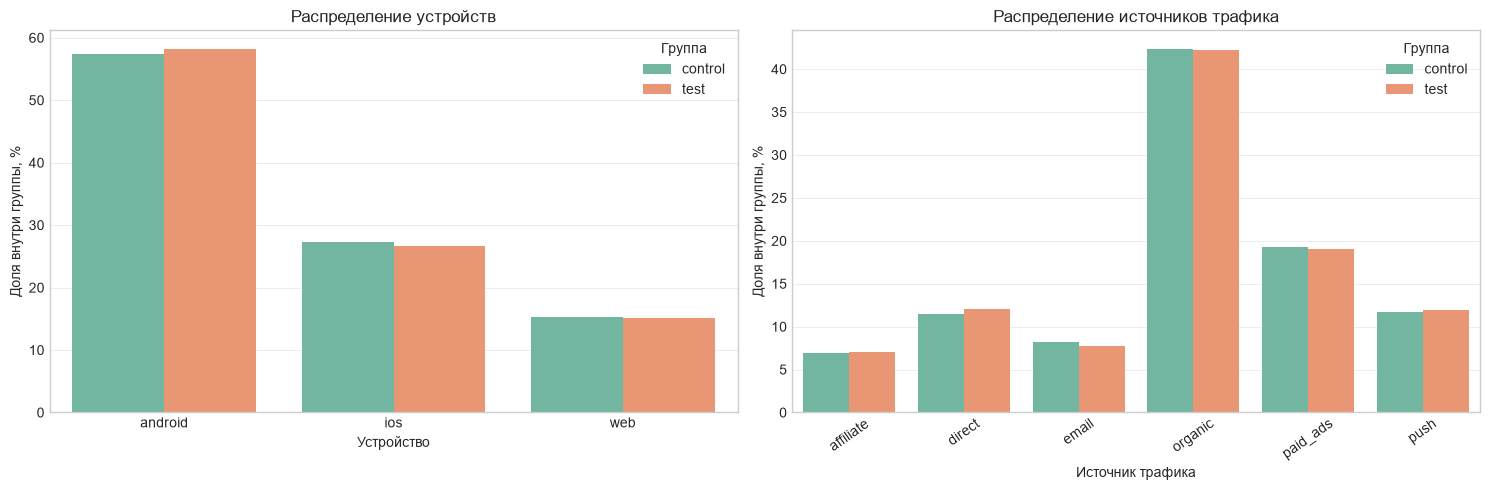

In [23]:
# Сначала самостоятельно рассчитываем доли устройств
device_plot = (
    analysis_users
    .groupby(['experiment_group', 'device'])
    .size()
    .reset_index(name='users')
)

device_plot['share_pct'] = (
    device_plot['users']
    / device_plot.groupby('experiment_group')['users'].transform('sum')
    * 100
)

# Аналогично рассчитываем доли источников трафика
traffic_plot = (
    analysis_users
    .groupby(['experiment_group', 'traffic_source'])
    .size()
    .reset_index(name='users')
)

traffic_plot['share_pct'] = (
    traffic_plot['users']
    / traffic_plot.groupby('experiment_group')['users'].transform('sum')
    * 100
)

# Строим графики по уже рассчитанным процентам
fig, axes = plt.subplots(
    1, 2,
    figsize=(15, 5)
)

sns.barplot(
    data=device_plot,
    x='device',
    y='share_pct',
    hue='experiment_group',
    ax=axes[0]
)

axes[0].set_title('Распределение устройств')
axes[0].set_xlabel('Устройство')
axes[0].set_ylabel('Доля внутри группы, %')
axes[0].legend(title='Группа')

sns.barplot(
    data=traffic_plot,
    x='traffic_source',
    y='share_pct',
    hue='experiment_group',
    ax=axes[1]
)

axes[1].set_title('Распределение источников трафика')
axes[1].set_xlabel('Источник трафика')
axes[1].set_ylabel('Доля внутри группы, %')
axes[1].tick_params(axis='x', rotation=35)
axes[1].legend(title='Группа')

plt.tight_layout()
plt.show()

In [24]:
tenure_summary = (
    analysis_users
    .groupby('experiment_group')
    .agg(
        users=('user_id', 'nunique'),
        mean_tenure_days=('tenure_days', 'mean'),
        median_tenure_days=('tenure_days', 'median'),
        std_tenure_days=('tenure_days', 'std')
    )
    .round(2)
    .reset_index()
)

display(tenure_summary)

,experiment_group,users,mean_tenure_days,median_tenure_days,std_tenure_days
0,control,24473,238.17,164.00,240.31
1,test,24828,239.25,165.00,238.76


### Вывод по структуре аудитории

Экспериментальные группы сопоставимы по устройствам, регионам, возрасту, источникам трафика, Premium-статусу и длительности присутствия пользователей на платформе. Максимальные различия в долях категорий не превышают одного процентного пункта.

Средний и медианный срок жизни пользователя также практически одинаковы. Существенных различий в структуре аудитории, способных самостоятельно объяснить последующие изменения продуктовых метрик, не обнаружено.

### 2.2 Анализ пользовательской активности

Рассчитаем количество сессий, просмотров страниц, показов, кликов и заказов на уровне пользователя. Метрики считаются для всех участников эксперимента, включая пользователей без кликов и покупок.

In [25]:
analysis_clicks = clean_clicks[
    clean_clicks['impression_id'].isin(
        analysis_impressions['impression_id']
    )
].copy()

print(f'Кликов до очистки: {len(clean_clicks)}')
print(f'Кликов после очистки: {len(analysis_clicks)}')
print(f'Исключено кликов: {len(clean_clicks) - len(analysis_clicks)}')

Кликов до очистки: 83191
Кликов после очистки: 82916
Исключено кликов: 275


In [26]:
session_activity = (
    clean_sessions
    .groupby('user_id')
    .agg(
        sessions=('session_id', 'nunique'),
        total_page_views=('page_views', 'sum'),
        mean_session_duration=(
            'session_duration_sec', 'mean'
        )
    )
    .reset_index()
)

impression_activity = (
    analysis_impressions
    .groupby('user_id')
    .agg(
        impressions=('impression_id', 'nunique')
    )
    .reset_index()
)

click_activity = (
    analysis_clicks
    .groupby('user_id')
    .agg(
        clicks=('click_id', 'nunique')
    )
    .reset_index()
)

order_activity = (
    clean_orders
    .groupby('user_id')
    .agg(
        orders=('order_id', 'nunique'),
        gmv_rub=('gmv_rub', 'sum')
    )
    .reset_index()
)

In [27]:
user_activity = (
    analysis_users[
        ['user_id', 'experiment_group']
    ]
    .merge(
        session_activity,
        on='user_id',
        how='left',
        validate='one_to_one'
    )
    .merge(
        impression_activity,
        on='user_id',
        how='left',
        validate='one_to_one'
    )
    .merge(
        click_activity,
        on='user_id',
        how='left',
        validate='one_to_one'
    )
    .merge(
        order_activity,
        on='user_id',
        how='left',
        validate='one_to_one'
    )
)

In [28]:
activity_columns = [
    'sessions',
    'total_page_views',
    'mean_session_duration',
    'impressions',
    'clicks',
    'orders',
    'gmv_rub'
]

user_activity[activity_columns] = (
    user_activity[activity_columns]
    .fillna(0)
)

In [29]:
activity_summary = (
    user_activity
    .groupby('experiment_group')
    .agg(
        users=('user_id', 'size'),

        active_users=(
            'sessions',
            lambda x: (x > 0).sum()
        ),

        avg_sessions=('sessions', 'mean'),
        median_sessions=('sessions', 'median'),

        avg_page_views=(
            'total_page_views', 'mean'
        ),

        avg_impressions=('impressions', 'mean'),
        median_impressions=('impressions', 'median'),

        avg_clicks=('clicks', 'mean'),
        median_clicks=('clicks', 'median'),

        buyers=(
            'orders',
            lambda x: (x > 0).sum()
        ),

        avg_orders=('orders', 'mean'),
        avg_gmv_per_user=('gmv_rub', 'mean')
    )
    .round(3)
    .reset_index()
)

display(activity_summary)

,experiment_group,users,active_users,avg_sessions,median_sessions,avg_page_views,avg_impressions,median_impressions,avg_clicks,median_clicks,buyers,avg_orders,avg_gmv_per_user
0,control,24473,24473,3.19,3.00,22.33,20.62,19.00,1.51,1.00,2890,0.13,211.15
1,test,24828,24828,3.19,3.00,22.31,20.56,18.00,1.85,1.00,3767,0.17,286.42


In [30]:
buyer_rate = (
    user_activity
    .groupby('experiment_group')
    .agg(
        users=('user_id', 'size'),
        buyers=('orders', lambda x: (x > 0).sum())
    )
)

buyer_rate['buyer_rate_pct'] = (
    buyer_rate['buyers']
    / buyer_rate['users']
    * 100
)

display(buyer_rate.round(2))

,users,buyers,buyer_rate_pct
experiment_group,,,
control,24473,2890,11.81
test,24828,3767,15.17


### Вывод по пользовательской активности

Интенсивность посещения маркетплейса практически одинакова между группами: в среднем 3,19 сессии и около 22,3 просмотра страниц на пользователя. Число показов рекомендаций также близко — около 20,6 на пользователя.

При сопоставимом количестве сессий и показов пользователи Test в среднем совершают больше кликов: 1,86 против 1,51. Доля пользователей хотя бы с одним заказом составляет около 15,17% в Test против 11,81% в Control. Средний GMV на участника эксперимента также выше: 286,42 рубля против 211,15 рубля.

Пока это описательные различия. Они ещё не доказывают эффект новой модели: статистическую значимость и размер эффекта проверим в разделе A/B-теста.

## 3. Анализ пользовательской воронки

Построим пользовательскую воронку:

участник эксперимента → показ → клик → заказ → возврат / повторная покупка.

Основная воронка считается на уровне уникальных пользователей. Дополнительно отдельно рассчитаем событийные CTR и Click-to-Order Conversion.

In [31]:
funnel_orders = clean_orders[
    clean_orders['click_id'].isin(
        analysis_clicks['click_id']
    )
].copy()

print(f'Показов в воронке: {len(analysis_impressions)}')
print(f'Кликов в воронке: {len(analysis_clicks)}')
print(f'Заказов в воронке: {len(funnel_orders)}')
print(
    'Заказов исключено из строгой воронки:',
    len(clean_orders) - len(funnel_orders)
)

Показов в воронке: 1015160
Кликов в воронке: 82916
Заказов в воронке: 7302
Заказов исключено из строгой воронки: 25


In [32]:
# Количество заказов каждого пользователя
user_order_counts = (
    funnel_orders
    .groupby('user_id')['order_id']
    .nunique()
)

# Пользователи хотя бы с одним возвратом
returned_user_ids = set(
    funnel_orders.loc[
        funnel_orders['is_returned'].eq(1),
        'user_id'
    ]
)

funnel_users = analysis_users[
    ['user_id', 'experiment_group']
].copy()

funnel_users['has_impression'] = (
    funnel_users['user_id'].isin(
        analysis_impressions['user_id']
    )
)

funnel_users['has_click'] = (
    funnel_users['user_id'].isin(
        analysis_clicks['user_id']
    )
)

funnel_users['has_order'] = (
    funnel_users['user_id'].isin(
        funnel_orders['user_id']
    )
)

funnel_users['has_return'] = (
    funnel_users['user_id'].isin(
        returned_user_ids
    )
)

funnel_users['is_repeat_buyer'] = (
    funnel_users['user_id']
    .map(user_order_counts)
    .fillna(0)
    .ge(2)
)

In [33]:
funnel_counts = (
    funnel_users
    .groupby('experiment_group')
    .agg(
        assigned_users=('user_id', 'size'),
        impression_users=('has_impression', 'sum'),
        click_users=('has_click', 'sum'),
        order_users=('has_order', 'sum'),
        return_users=('has_return', 'sum'),
        repeat_buyers=('is_repeat_buyer', 'sum')
    )
)

display(funnel_counts)

,assigned_users,impression_users,click_users,order_users,return_users,repeat_buyers
experiment_group,,,,,,
control,24473,24472,17488,2881,171,203
test,24828,24828,19238,3759,286,404


In [34]:
funnel_share = funnel_counts.copy()

funnel_share = (
    funnel_share
    .div(funnel_share['assigned_users'], axis=0)
    * 100
)

display(funnel_share.round(2))

,assigned_users,impression_users,click_users,order_users,return_users,repeat_buyers
experiment_group,,,,,,
control,100.00,100.00,71.46,11.77,0.70,0.83
test,100.00,100.00,77.49,15.14,1.15,1.63


In [35]:
funnel_conversion = pd.DataFrame(
    index=funnel_counts.index
)

funnel_conversion['impression_to_click_pct'] = (
    funnel_counts['click_users']
    / funnel_counts['impression_users']
    * 100
)

funnel_conversion['click_to_order_pct'] = (
    funnel_counts['order_users']
    / funnel_counts['click_users']
    * 100
)

funnel_conversion['order_to_return_pct'] = (
    funnel_counts['return_users']
    / funnel_counts['order_users']
    * 100
)

funnel_conversion['repeat_buyer_pct'] = (
    funnel_counts['repeat_buyers']
    / funnel_counts['order_users']
    * 100
)

display(funnel_conversion.round(2))

,impression_to_click_pct,click_to_order_pct,order_to_return_pct,repeat_buyer_pct
experiment_group,,,,
control,71.46,16.47,5.94,7.05
test,77.49,19.54,7.61,10.75


CTR = количество кликнутых показов / все показы

In [36]:
impressions_with_group = (
    analysis_impressions
    .merge(
        clean_assignments[
            ['user_id', 'experiment_group']
        ],
        on='user_id',
        how='inner',
        validate='many_to_one'
    )
)

orders_funnel_with_group = (
    funnel_orders
    .merge(
        clean_assignments[
            ['user_id', 'experiment_group']
        ],
        on='user_id',
        how='inner',
        validate='many_to_one'
    )
)

event_funnel = (
    impressions_with_group
    .groupby('experiment_group')
    .agg(
        impressions=('impression_id', 'size'),
        clicks=('is_clicked', 'sum')
    )
)

orders_by_group = (
    orders_funnel_with_group
    .groupby('experiment_group')
    .size()
)

event_funnel['orders'] = orders_by_group

event_funnel['ctr_pct'] = (
    event_funnel['clicks']
    / event_funnel['impressions']
    * 100
)

event_funnel['click_to_order_pct'] = (
    event_funnel['orders']
    / event_funnel['clicks']
    * 100
)

display(event_funnel.round(3))

,impressions,clicks,orders,ctr_pct,click_to_order_pct
experiment_group,,,,,
control,504604,36851,3098,7.30,8.41
test,510556,46065,4204,9.02,9.13


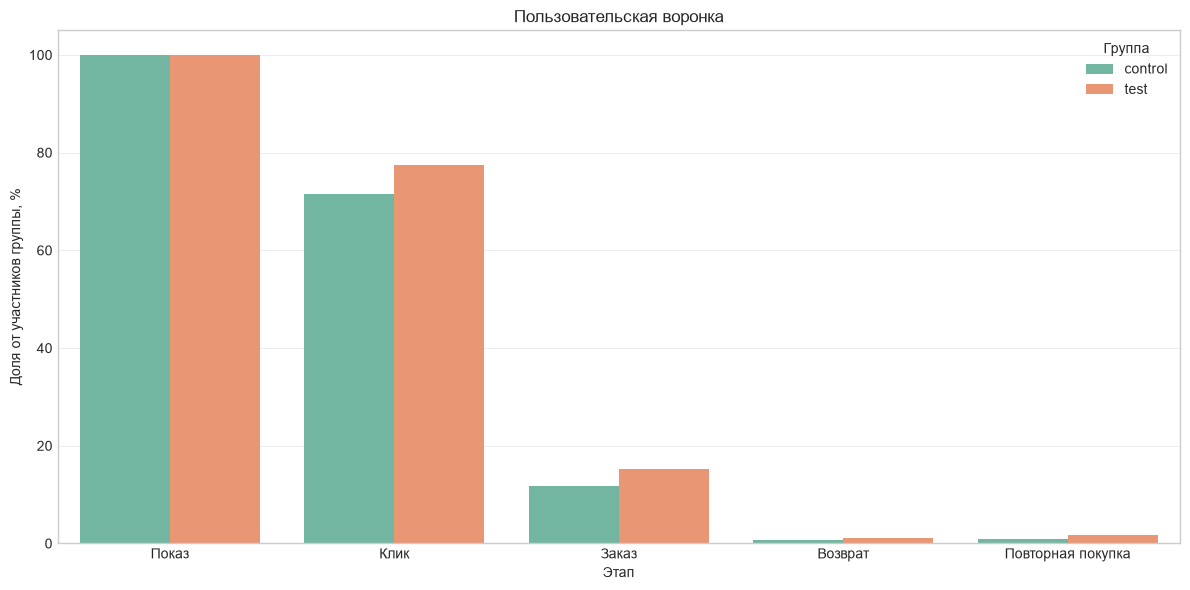

In [37]:
funnel_plot = (
    funnel_share[
        [
            'impression_users',
            'click_users',
            'order_users',
            'return_users',
            'repeat_buyers'
        ]
    ]
    .reset_index()
    .melt(
        id_vars='experiment_group',
        var_name='stage',
        value_name='share_pct'
    )
)

stage_labels = {
    'impression_users': 'Показ',
    'click_users': 'Клик',
    'order_users': 'Заказ',
    'return_users': 'Возврат',
    'repeat_buyers': 'Повторная покупка'
}

funnel_plot['stage'] = (
    funnel_plot['stage'].map(stage_labels)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=funnel_plot,
    x='stage',
    y='share_pct',
    hue='experiment_group'
)

plt.title('Пользовательская воронка')
plt.xlabel('Этап')
plt.ylabel('Доля от участников группы, %')
plt.legend(title='Группа')
plt.tight_layout()
plt.show()

In [38]:
print('1. Количество пользователей на каждом этапе')
display(funnel_counts)

print('2. Пользовательские конверсии между этапами')
display(funnel_conversion.round(2))

print('3. Событийная воронка')
display(event_funnel.round(3))

1. Количество пользователей на каждом этапе


,assigned_users,impression_users,click_users,order_users,return_users,repeat_buyers
experiment_group,,,,,,
control,24473,24472,17488,2881,171,203
test,24828,24828,19238,3759,286,404


2. Пользовательские конверсии между этапами


,impression_to_click_pct,click_to_order_pct,order_to_return_pct,repeat_buyer_pct
experiment_group,,,,
control,71.46,16.47,5.94,7.05
test,77.49,19.54,7.61,10.75


3. Событийная воронка


,impressions,clicks,orders,ctr_pct,click_to_order_pct
experiment_group,,,,,
control,504604,36851,3098,7.30,8.41
test,510556,46065,4204,9.02,9.13


### Вывод по пользовательской воронке

При практически полном охвате показами новая модель улучшает переход к целевым действиям. Хотя бы один клик совершили 77,49% пользователей Test против 71,46% в Control. До заказа дошли 15,14% пользователей Test против 11,77% в Control.

Событийный CTR составляет 9,02% в Test и 7,30% в Control. Click-to-Order Conversion также выше: 9,13% против 8,41%.

Одновременно в Test выше доля покупателей с возвратом: 7,61% против 5,94%. Доля повторных покупателей также выше: 10,75% против 7,05%.

Таким образом, новая модель предварительно улучшает клики, покупки и повторные покупки, но возможный рост возвратов представляет бизнес-риск. Статистическую значимость каждого различия проверим в разделе A/B-теста.

Основное узкое место воронки находится на переходе от клика к заказу: покупку совершают 16,47% кликнувших пользователей Control и 19,54% Test. Несмотря на улучшение этого перехода в Test, большая часть кликнувших пользователей не доходит до заказа.

Возврат и повторная покупка рассматриваются как отдельные постпокупочные результаты, а не как последовательные этапы одной воронки.

## 4. Анализ результатов A/B-теста

В предыдущем разделе были обнаружены различия между Control и Test в кликах, покупках, возвратах и повторных покупках. Однако само наличие различий ещё не доказывает влияние новой рекомендательной модели.

На этом этапе проверим статистическую значимость изменений и оценим не только направление, но и величину эффекта.

### 4.1 Выбор метрик

Для оценки результатов эксперимента используются:

- **CTR на пользователя** — характеризует интерес пользователей к рекомендациям;
- **конверсия в покупателя** — доля пользователей, совершивших хотя бы один заказ;
- **заказы на пользователя** — среднее количество заказов на одного участника эксперимента;
- **GMV на пользователя** — оборот маркетплейса на одного участника;
- **gross margin на пользователя** — краткосрочная коммерческая ценность участника эксперимента;
- **доля повторных покупателей** — доля всех участников, совершивших не менее двух заказов;
- **Premium Conversion** — доля новых подписчиков среди пользователей без Premium на начало эксперимента;
- **доля пользователей с возвратом** — защитная метрика качества покупок;
- **доля пользователей с обращением в поддержку** — защитная метрика пользовательского опыта.

Дополнительно для бизнес-интерпретации рассчитываются:

- **Average Order Value (AOV)** — средний оборот одного заказа;
- **gross margin на заказ** — средняя маржа одного оформленного заказа;
- **order-level Return Rate** — доля возвращённых заказов;
- **gross margin rate** — отношение gross margin к GMV.

Основными показателями для принятия решения считаются конверсия пользователя в покупателя и gross margin на пользователя. CTR оценивает эффективность рекомендаций, а возвраты и обращения в поддержку выступают guardrail-метриками, ограничивающими допустимую цену роста.

### 4.2 Формирование пользовательской витрины

Поскольку единицей рандомизации является пользователь, перед статистическим анализом события агрегируются до уровня `user_id`.

Для каждого пользователя рассчитываются:

- количество показов и кликов;
- количество заказов;
- GMV и gross margin;
- количество возвратов;
- количество обращений в поддержку.

На следующем этапе агрегаты будут присоединены к полной таблице участников эксперимента. Пользователи без соответствующих событий останутся в выборке и получат нулевые значения.
В статистическом анализе используется строгая событийная цепочка `funnel_orders`. Из неё исключены 25 заказов, связанных с показами, отмеченными как дублирующиеся события.

Поэтому значения GMV и доли покупателей могут незначительно отличаться от результатов EDA, где для общего описания активности использовались все заказы очищенных пользователей.

In [39]:
# 1. Показы и клики на уровне пользователя
user_impressions = (
    analysis_impressions
    .groupby('user_id')
    .agg(
        impressions=('impression_id', 'nunique'),
        clicks=('is_clicked', 'sum')
    )
    .reset_index()
)

# 2. Заказы и их денежные показатели
user_orders = (
    funnel_orders
    .groupby('user_id')
    .agg(
        orders=('order_id', 'nunique'),
        gmv_rub=('gmv_rub', 'sum'),
        gross_margin_rub=('gross_margin_rub', 'sum'),
        returned_orders=('is_returned', 'sum')
    )
    .reset_index()
)

# 3. Оставляем обращения, относящиеся к чистой цепочке заказов
analysis_support = clean_support[
    clean_support['order_id'].isin(
        funnel_orders['order_id']
    )
].copy()

# 4. Обращения в поддержку на уровне пользователя
user_support = (
    analysis_support
    .groupby('user_id')
    .agg(
        support_tickets=('ticket_id', 'nunique')
    )
    .reset_index()
)

print('Агрегаты показов:')
display(user_impressions.head())

print('Агрегаты заказов:')
display(user_orders.head())

print('Агрегаты поддержки:')
display(user_support.head())

print('Размеры таблиц:')
print(f'Пользователей с показами: {len(user_impressions)}')
print(f'Покупателей: {len(user_orders)}')
print(f'Пользователей с обращениями: {len(user_support)}')

Агрегаты показов:


,user_id,impressions,clicks
0,u_000001,15,1
1,u_000002,6,0
2,u_000003,21,1
3,u_000004,14,0
4,u_000005,25,1


Агрегаты заказов:


,user_id,orders,gmv_rub,gross_margin_rub,returned_orders
0,u_000007,1,4374,879.17,0
1,u_000020,1,2690,407.27,0
2,u_000024,1,189,28.92,0
3,u_000028,1,614,127.83,0
4,u_000037,1,363,50.31,0


Агрегаты поддержки:


,user_id,support_tickets
0,u_000020,1
1,u_000060,1
2,u_000303,1
3,u_000374,1
4,u_000399,1


Размеры таблиц:
Пользователей с показами: 49300
Покупателей: 6640
Пользователей с обращениями: 332


In [40]:
metric_users = (
    analysis_users
    .merge(
        user_impressions,
        on='user_id',
        how='left',
        validate='one_to_one'
    )
    .merge(
        user_orders,
        on='user_id',
        how='left',
        validate='one_to_one'
    )
    .merge(
        user_support,
        on='user_id',
        how='left',
        validate='one_to_one'
    )
)

print(f'Строк в пользовательской витрине: {len(metric_users)}')
print(f'Уникальных пользователей: {metric_users["user_id"].nunique()}')

display(metric_users.head())

Строк в пользовательской витрине: 49301
Уникальных пользователей: 49301


,user_id,registration_date,region,device,age_group,traffic_source,is_premium,is_bot_candidate,experiment_group,tenure_days,impressions,clicks,orders,gmv_rub,gross_margin_rub,returned_orders,support_tickets
0,u_000001,2026-04-29,Volga,android,18-24,paid_ads,0,0,control,63,15.00,1.00,NaN,NaN,NaN,NaN,NaN
1,u_000002,2026-02-25,Central Russia,android,35-44,direct,0,0,test,126,6.00,0.00,NaN,NaN,NaN,NaN,NaN
2,u_000003,2026-04-01,Moscow,web,18-24,push,1,0,control,91,21.00,1.00,NaN,NaN,NaN,NaN,NaN
3,u_000004,2026-03-08,Ural,ios,25-34,paid_ads,0,0,control,115,14.00,0.00,NaN,NaN,NaN,NaN,NaN
4,u_000005,2025-07-28,Central Russia,android,18-24,organic,1,0,test,338,25.00,1.00,NaN,NaN,NaN,NaN,NaN


In [41]:
zero_columns = [
    'impressions',
    'clicks',
    'orders',
    'gmv_rub',
    'gross_margin_rub',
    'returned_orders',
    'support_tickets'
]

metric_users[zero_columns] = (
    metric_users[zero_columns].fillna(0)
)

print('Количество пропусков после заполнения:')
display(metric_users[zero_columns].isna().sum())

Количество пропусков после заполнения:


impressions         0
clicks              0
orders              0
gmv_rub             0
gross_margin_rub    0
returned_orders     0
support_tickets     0
dtype: int64

После объединения агрегатов пользователи без соответствующих событий получили пропуски. В данном случае пропуск означает отсутствие события, поэтому значения количества показов, кликов, заказов, возвратов, обращений, а также GMV и gross margin были заменены на нули.

После объединения витрина содержит 49 301 строку и 49 301 уникального пользователя. Следовательно, каждый участник эксперимента представлен ровно одной строкой, а объединения не привели к размножению наблюдений.

In [42]:
metric_users['user_ctr'] = np.where(
    metric_users['impressions'] > 0,
    metric_users['clicks'] / metric_users['impressions'],
    0
)

metric_users['clicked_any'] = (
    metric_users['clicks'] > 0
)

metric_users['buyer'] = (
    metric_users['orders'] > 0
)

metric_users['repeat_buyer'] = (
    metric_users['orders'] >= 2
)

metric_users['return_any'] = (
    metric_users['returned_orders'] > 0
)

metric_users['support_any'] = (
    metric_users['support_tickets'] > 0
)

display(
    metric_users[
        [
            'user_id',
            'experiment_group',
            'impressions',
            'clicks',
            'user_ctr',
            'orders',
            'buyer',
            'repeat_buyer',
            'gmv_rub',
            'gross_margin_rub',
            'return_any',
            'support_any'
        ]
    ].head(15)
)

,user_id,experiment_group,impressions,clicks,user_ctr,orders,buyer,repeat_buyer,gmv_rub,gross_margin_rub,return_any,support_any
0,u_000001,control,15.00,1.00,0.07,0.00,False,False,0.00,0.00,False,False
1,u_000002,test,6.00,0.00,0.00,0.00,False,False,0.00,0.00,False,False
2,u_000003,control,21.00,1.00,0.05,0.00,False,False,0.00,0.00,False,False
3,u_000004,control,14.00,0.00,0.00,0.00,False,False,0.00,0.00,False,False
4,u_000005,test,25.00,1.00,0.04,0.00,False,False,0.00,0.00,False,False
5,u_000006,control,6.00,1.00,0.17,0.00,False,False,0.00,0.00,False,False
6,u_000007,control,22.00,3.00,0.14,1.00,True,False,4374.00,879.17,False,False
7,u_000008,test,8.00,1.00,0.12,0.00,False,False,0.00,0.00,False,False
8,u_000009,test,9.00,1.00,0.11,0.00,False,False,0.00,0.00,False,False
9,u_000010,test,9.00,1.00,0.11,0.00,False,False,0.00,0.00,False,False


Поле `gross_margin_rub` уже содержится в таблице заказов и представляет приблизительную маржу заказа, рассчитанную авторами датасета. В рамках анализа формула формирования этой величины неизвестна, поэтому показатель используется в готовом виде.

Для возвращённых заказов в датасете указана небольшая отрицательная маржа. Следовательно, суммарная gross margin частично учитывает последствия возвратов, но не может интерпретироваться как чистая прибыль компании: в данных отсутствует полный состав операционных расходов.

### 4.3 Описательное сравнение пользовательских метрик

Сначала сравним средние значения и доли метрик между экспериментальными группами. На этом этапе различия рассматриваются описательно: статистическая значимость будет проверена отдельно.

In [43]:
group_summary = (
    metric_users
    .groupby('experiment_group')
    .agg(
        users=('user_id', 'nunique'),
        avg_user_ctr=('user_ctr', 'mean'),
        clicked_user_share=('clicked_any', 'mean'),
        buyer_share=('buyer', 'mean'),
        orders_per_user=('orders', 'mean'),
        gmv_per_user=('gmv_rub', 'mean'),
        gross_margin_per_user=('gross_margin_rub', 'mean'),
        repeat_buyer_share=('repeat_buyer', 'mean'),
        return_user_share=('return_any', 'mean'),
        support_user_share=('support_any', 'mean')
    )
    .reset_index()
)

# Переводим доли из формата 0–1 в проценты
percentage_columns = [
    'avg_user_ctr',
    'clicked_user_share',
    'buyer_share',
    'repeat_buyer_share',
    'return_user_share',
    'support_user_share'
]

group_summary[percentage_columns] = (
    group_summary[percentage_columns] * 100
)

display(group_summary.round(2))

,experiment_group,users,avg_user_ctr,clicked_user_share,buyer_share,orders_per_user,gmv_per_user,gross_margin_per_user,repeat_buyer_share,return_user_share,support_user_share
0,control,24473,7.53,71.46,11.77,0.13,209.80,34.96,0.83,0.70,0.54
1,test,24828,9.32,77.49,15.14,0.17,285.58,46.14,1.63,1.15,0.81


На пользовательском уровне Test превосходит Control по всем продуктовым и бизнес-метрикам. Средний пользовательский CTR вырос с 7,53% до 9,32%, доля покупателей — с 11,77% до 15,14%, GMV на пользователя — с 209,80 до 285,58 руб., а gross margin на пользователя — с 34,96 до 46,14 руб.

Одновременно ухудшились защитные метрики: доля пользователей с возвратом выросла с 0,70% до 1,15%, а доля пользователей с обращением в поддержку — с 0,54% до 0,81%.

На данном этапе нельзя утверждать, что изменения вызваны новой моделью: необходимо оценить размер эффектов, доверительные интервалы и статистическую значимость различий.

#### Событийный и пользовательский CTR

Событийный CTR рассчитывается как отношение общего количества кликов к общему количеству показов. В таком расчёте каждый показ имеет одинаковый вес, поэтому пользователи с большим количеством показов сильнее влияют на результат.

Пользовательский CTR сначала рассчитывается отдельно для каждого участника, после чего полученные значения усредняются. Таким образом, каждый пользователь имеет одинаковый вес.

Поскольку экспериментальная группа назначалась на уровне пользователя, статистическую значимость CTR будем оценивать по пользовательским наблюдениям. Событийный CTR оставим описательной метрикой эффективности всех показов.

### 4.4 Принципы оценки эффекта

Для каждой метрики оцениваются:

- значение в Control и Test;
- абсолютный эффект как разность `Test − Control`;
- относительный эффект относительно Control;
- 95%-й доверительный интервал эффекта.

Для долей абсолютный эффект выражается в процентных пунктах. Например, рост конверсии с 11,77% до 15,14% составляет 3,37 п.п., или примерно 28,6% относительно Control.

Доверительный интервал показывает диапазон статистически правдоподобных значений эффекта. Если интервал не содержит ноль, данные поддерживают наличие различия между группами. При этом ширина интервала позволяет оценить точность полученного результата.

### 4.5 Статистические гипотезы

Для каждой метрики проверяется нулевая гипотеза:

> \(H_0\): значение метрики в Test равно значению в Control, а наблюдаемая разница объясняется случайными колебаниями выборки.

Альтернативная гипотеза:

> \(H_1\): значения метрики в Test и Control различаются.

Используется двусторонний уровень значимости 5%. При `p-value < 0,05` нулевая гипотеза отклоняется, и различие считается статистически значимым. При `p-value ≥ 0,05` данных недостаточно для подтверждения различия.

p-value не показывает вероятность истинности нулевой гипотезы и не характеризует бизнес-ценность эффекта. Направление и практическая значимость изменения оцениваются отдельно по размеру эффекта и доверительному интервалу.

### 4.6 Выбор статистических методов

Для сравнения экспериментальных групп используются следующие методы:

- для бинарных метрик применяется тест разности долей;
- для количественных метрик применяется t-тест Уэлча;
- для каждого эффекта рассчитываются абсолютное и относительное изменения, 95% доверительный интервал и p-value;
- уровень статистической значимости принят равным 0,05.

Расчёты проводятся на пользовательском уровне, поскольку единицей рандомизации в эксперименте является пользователь.

### 4.7 Проверка бинарных метрик

Для бинарных метрик сравниваются доли пользователей в группах Control и Test.

Проверяются следующие показатели:

- доля пользователей, совершивших хотя бы один клик;
- конверсия пользователя в покупателя;
- доля повторных покупателей среди всех пользователей;
- доля пользователей с возвратом;
- доля пользователей, обратившихся в поддержку.

Для каждой метрики рассчитываются значение в обеих группах, абсолютный и относительный эффекты, 95% доверительный интервал абсолютного эффекта и p-value.

In [44]:
from scipy.stats import norm
import numpy as np
import pandas as pd


def binary_metric_test(data, metric, metric_name):
    control = data.loc[
        data['experiment_group'] == 'control', metric
    ].astype(int)

    test = data.loc[
        data['experiment_group'] == 'test', metric
    ].astype(int)

    n_control = len(control)
    n_test = len(test)

    successes_control = control.sum()
    successes_test = test.sum()

    control_rate = control.mean()
    test_rate = test.mean()

    absolute_effect = test_rate - control_rate
    relative_effect = absolute_effect / control_rate * 100

    # Стандартная ошибка для доверительного интервала
    ci_standard_error = np.sqrt(
        control_rate * (1 - control_rate) / n_control
        + test_rate * (1 - test_rate) / n_test
    )

    ci_low = absolute_effect - 1.96 * ci_standard_error
    ci_high = absolute_effect + 1.96 * ci_standard_error

    # Объединённая доля для проверки нулевой гипотезы
    pooled_rate = (
        successes_control + successes_test
    ) / (n_control + n_test)

    test_standard_error = np.sqrt(
        pooled_rate * (1 - pooled_rate)
        * (1 / n_control + 1 / n_test)
    )

    z_stat = absolute_effect / test_standard_error
    p_value = 2 * norm.sf(abs(z_stat))

    return {
        'metric': metric_name,
        'control_pct': control_rate * 100,
        'test_pct': test_rate * 100,
        'absolute_effect_pp': absolute_effect * 100,
        'relative_effect_pct': relative_effect,
        'ci_low_pp': ci_low * 100,
        'ci_high_pp': ci_high * 100,
        'p_value': p_value
    }

In [45]:
binary_metrics = {
    'clicked_any': 'Пользователь совершил клик',
    'buyer': 'Пользователь совершил покупку',
    'repeat_buyer': 'Повторная покупка',
    'return_any': 'Пользователь с возвратом',
    'support_any': 'Пользователь с обращением в поддержку'
}

binary_results = pd.DataFrame([
    binary_metric_test(metric_users, metric, metric_name)
    for metric, metric_name in binary_metrics.items()
])

binary_results.round({
    'control_pct': 2,
    'test_pct': 2,
    'absolute_effect_pp': 2,
    'relative_effect_pct': 2,
    'ci_low_pp': 2,
    'ci_high_pp': 2,
    'p_value': 6
})

,metric,control_pct,test_pct,absolute_effect_pp,relative_effect_pct,ci_low_pp,ci_high_pp,p_value
0,Пользователь совершил клик,71.46,77.49,6.03,8.43,5.26,6.79,0.00
1,Пользователь совершил покупку,11.77,15.14,3.37,28.61,2.77,3.97,0.00
2,Повторная покупка,0.83,1.63,0.80,96.17,0.60,0.99,0.00
3,Пользователь с возвратом,0.70,1.15,0.45,64.86,0.28,0.62,0.00
4,Пользователь с обращением в поддержку,0.54,0.81,0.27,51.24,0.13,0.42,0.00


In [46]:
binary_results_display = binary_results.copy()

binary_results_display[
    [
        'control_pct',
        'test_pct',
        'absolute_effect_pp',
        'relative_effect_pct',
        'ci_low_pp',
        'ci_high_pp'
    ]
] = binary_results_display[
    [
        'control_pct',
        'test_pct',
        'absolute_effect_pp',
        'relative_effect_pct',
        'ci_low_pp',
        'ci_high_pp'
    ]
].round(2)

binary_results_display.style.format({
    'control_pct': '{:.2f}',
    'test_pct': '{:.2f}',
    'absolute_effect_pp': '{:+.2f}',
    'relative_effect_pct': '{:+.2f}',
    'ci_low_pp': '{:+.2f}',
    'ci_high_pp': '{:+.2f}',
    'p_value': '{:.2e}'
})

,metric,control_pct,test_pct,absolute_effect_pp,relative_effect_pct,ci_low_pp,ci_high_pp,p_value
0,Пользователь совершил клик,71.46,77.49,+6.03,+8.43,+5.26,+6.79,3.59e-53
1,Пользователь совершил покупку,11.77,15.14,+3.37,+28.61,+2.77,+3.97,6.46e-28
2,Повторная покупка,0.83,1.63,+0.80,+96.17,+0.60,+0.99,9.69e-16
3,Пользователь с возвратом,0.70,1.15,+0.45,+64.86,+0.28,+0.62,1.52e-07
4,Пользователь с обращением в поддержку,0.54,0.81,+0.27,+51.24,+0.13,+0.42,1.97e-04


#### Вывод по бинарным метрикам

В группе Test статистически значимо выросла доля пользователей, совершивших хотя бы один клик: с 71,46% до 77,49% — на 6,03 п.п. (+8,43% относительно Control).

Конверсия пользователя в покупателя увеличилась с 11,77% до 15,14%. Абсолютный эффект составил +3,37 п.п., относительный — +28,61%. 95% доверительный интервал абсолютного эффекта составляет от +2,77 до +3,97 п.п.

Доля всех пользователей, совершивших повторную покупку, выросла с 0,83% до 1,63%, или на 0,80 п.п.

Одновременно выросли негативные показатели: доля пользователей с возвратом увеличилась с 0,70% до 1,15% (+0,45 п.п.), а доля пользователей с обращением в поддержку — с 0,54% до 0,81% (+0,27 п.п.).

Для всех рассмотренных метрик p-value меньше 0,05, а доверительные интервалы эффектов не включают ноль. Следовательно, обнаруженные различия являются статистически значимыми. Новая модель улучшает клики, покупки и повторные покупки, но одновременно усиливает риски возвратов и обращений в поддержку.1

### 4.8 Проверка количественных метрик

Для сравнения средних значений количественных метрик применяется двухсторонний t-тест Уэлча.

Анализируются:

- пользовательский CTR;
- количество заказов на пользователя;
- GMV на пользователя;
- gross margin на пользователя.

В расчёты включаются все пользователи экспериментальных групп. Пользователи без заказов имеют нулевые значения заказов, GMV и gross margin. Это позволяет оценить итоговый эффект эксперимента на одного назначенного пользователя.

In [47]:
from scipy.stats import ttest_ind, t


def numeric_metric_test(data, metric, metric_name):
    control = data.loc[
        data['experiment_group'] == 'control', metric
    ].astype(float)

    test = data.loc[
        data['experiment_group'] == 'test', metric
    ].astype(float)

    n_control = len(control)
    n_test = len(test)

    control_mean = control.mean()
    test_mean = test.mean()

    absolute_effect = test_mean - control_mean
    relative_effect = absolute_effect / control_mean * 100

    control_variance = control.var(ddof=1)
    test_variance = test.var(ddof=1)

    # Стандартная ошибка разности средних
    standard_error = np.sqrt(
        control_variance / n_control
        + test_variance / n_test
    )

    # Число степеней свободы по формуле Уэлча
    degrees_of_freedom = (
        control_variance / n_control
        + test_variance / n_test
    ) ** 2 / (
        (control_variance / n_control) ** 2 / (n_control - 1)
        + (test_variance / n_test) ** 2 / (n_test - 1)
    )

    critical_value = t.ppf(
        0.975,
        df=degrees_of_freedom
    )

    ci_low = absolute_effect - critical_value * standard_error
    ci_high = absolute_effect + critical_value * standard_error

    _, p_value = ttest_ind(
        test,
        control,
        equal_var=False
    )

    return {
        'metric': metric_name,
        'control_mean': control_mean,
        'test_mean': test_mean,
        'absolute_effect': absolute_effect,
        'relative_effect_pct': relative_effect,
        'ci_low': ci_low,
        'ci_high': ci_high,
        'p_value': p_value
    }

In [48]:
numeric_metrics = {
    'user_ctr': 'Пользовательский CTR',
    'orders': 'Заказы на пользователя',
    'gmv_rub': 'GMV на пользователя',
    'gross_margin_rub': 'Gross margin на пользователя'
}

numeric_results = pd.DataFrame([
    numeric_metric_test(metric_users, metric, metric_name)
    for metric, metric_name in numeric_metrics.items()
])

# Для CTR переводим средние и абсолютный эффект из долей в проценты
ctr_mask = numeric_results['metric'] == 'Пользовательский CTR'

numeric_results.loc[
    ctr_mask,
    ['control_mean', 'test_mean', 'absolute_effect', 'ci_low', 'ci_high']
] *= 100

numeric_results.style.format({
    'control_mean': '{:.2f}',
    'test_mean': '{:.2f}',
    'absolute_effect': '{:+.2f}',
    'relative_effect_pct': '{:+.2f}',
    'ci_low': '{:+.2f}',
    'ci_high': '{:+.2f}',
    'p_value': '{:.2e}'
})

,metric,control_mean,test_mean,absolute_effect,relative_effect_pct,ci_low,ci_high,p_value
0,Пользовательский CTR,7.53,9.32,+1.80,+23.90,+1.66,+1.94,4.83e-137
1,Заказы на пользователя,0.13,0.17,+0.04,+33.76,+0.04,+0.05,1.78e-33
2,GMV на пользователя,209.80,285.58,+75.78,+36.12,+59.73,+91.82,2.20e-20
3,Gross margin на пользователя,34.96,46.14,+11.18,+31.96,+8.60,+13.75,1.90e-17


#### Вывод по количественным метрикам

Новая модель статистически значимо улучшила все исследованные количественные показатели.

Средний пользовательский CTR вырос с 7,53% до 9,32%. Абсолютный эффект составил +1,80 п.п., относительный — +23,90%. 95% доверительный интервал абсолютного эффекта составляет от +1,66 до +1,94 п.п.

Среднее количество заказов на одного назначенного пользователя увеличилось с 0,13 до 0,17, или на 33,76% относительно Control.

GMV на пользователя вырос с 209,80 ₽ до 285,58 ₽. Абсолютный эффект составил +75,78 ₽, относительный — +36,12%, а 95% доверительный интервал — от +59,73 до +91,82 ₽.

Gross margin на пользователя увеличилась с 34,96 ₽ до 46,14 ₽. Абсолютный эффект составил +11,18 ₽ на пользователя, относительный — +31,96%. 95% доверительный интервал составляет от +8,60 до +13,75 ₽.

Для всех количественных метрик p-value значительно меньше 0,05, а доверительные интервалы не включают ноль. Следовательно, рост метрик статистически значим и не ограничивается увеличением кликов: новая модель повышает количество заказов, оборот и gross margin на одного пользователя.

### 4.9 Premium Conversion

Конверсия в Premium рассчитывается только среди пользователей, которые не имели Premium на момент начала эксперимента.

Целевым событием считается начало Premium-подписки в течение экспериментального окна. Действующие Premium-пользователи исключаются из знаменателя, поскольку они не могли повторно сконвертироваться в новую подписку.

In [49]:
# Преобразуем дату начала Premium-подписки
clean_premium['premium_start_date'] = pd.to_datetime(
    clean_premium['premium_start_date']
)

# Пользователи, начавшие Premium-подписку во время эксперимента
new_premium_ids = set(
    clean_premium.loc[
        clean_premium['premium_start_date'].between(
            experiment_start,
            experiment_end
        ),
        'user_id'
    ]
)

# Добавляем бинарный признак в пользовательскую витрину
metric_users['new_premium'] = (
    metric_users['user_id'].isin(new_premium_ids)
)

# В знаменателе только пользователи без Premium на старте
premium_eligible = metric_users.loc[
    metric_users['is_premium'].eq(0)
].copy()

print(
    'Пользователей без Premium на старте:',
    len(premium_eligible)
)

print(
    'Новых Premium-пользователей:',
    premium_eligible['new_premium'].sum()
)

Пользователей без Premium на старте: 41151
Новых Premium-пользователей: 859


In [50]:
premium_result = pd.DataFrame([
    binary_metric_test(
        premium_eligible,
        'new_premium',
        'Новая Premium-подписка'
    )
])

premium_result.style.format({
    'control_pct': '{:.2f}',
    'test_pct': '{:.2f}',
    'absolute_effect_pp': '{:+.2f}',
    'relative_effect_pct': '{:+.2f}',
    'ci_low_pp': '{:+.2f}',
    'ci_high_pp': '{:+.2f}',
    'p_value': '{:.2e}'
})

,metric,control_pct,test_pct,absolute_effect_pp,relative_effect_pct,ci_low_pp,ci_high_pp,p_value
0,Новая Premium-подписка,1.81,2.36,+0.55,+30.09,+0.27,+0.82,1.08e-04


### 4.10 Поправка на множественные проверки
Поскольку в рамках анализа одновременно проверяется несколько метрик, возрастает вероятность случайного получения статистически значимого результата.

Для контроля доли ложноположительных выводов применяется поправка Бенджамини — Хохберга (FDR) с уровнем значимости 0,05. Корректировка проводится совместно для бинарных и количественных метрик.

In [51]:
from statsmodels.stats.multitest import multipletests


all_p_values = pd.concat(
    [
        binary_results[['metric', 'p_value']],
        numeric_results[['metric', 'p_value']],
        premium_result[['metric', 'p_value']]
    ],
    ignore_index=True
)

reject_h0, adjusted_p_values, _, _ = multipletests(
    all_p_values['p_value'],
    alpha=0.05,
    method='fdr_bh'
)

all_p_values['adjusted_p_value'] = adjusted_p_values
all_p_values['significant_after_fdr'] = reject_h0

all_p_values.style.format({
    'p_value': '{:.2e}',
    'adjusted_p_value': '{:.2e}'
})

,metric,p_value,adjusted_p_value,significant_after_fdr
0,Пользователь совершил клик,3.59e-53,1.79e-52,True
1,Пользователь совершил покупку,6.46e-28,1.61e-27,True
2,Повторная покупка,9.69e-16,1.38e-15,True
3,Пользователь с возвратом,1.52e-07,1.90e-07,True
4,Пользователь с обращением в поддержку,1.97e-04,1.97e-04,True
5,Пользовательский CTR,4.83e-137,4.83e-136,True
6,Заказы на пользователя,1.78e-33,5.94e-33,True
7,GMV на пользователя,2.20e-20,4.40e-20,True
8,Gross margin на пользователя,1.90e-17,3.17e-17,True
9,Новая Premium-подписка,1.08e-04,1.20e-04,True


#### Вывод по множественным проверкам

После применения поправки Бенджамини — Хохберга все десять исследованных метрик сохранили статистическую значимость: для каждой из них скорректированный p-value оказался меньше 0,05.

Следовательно, выводы об улучшении пользовательского CTR, конверсии в покупку, повторных покупок, количества заказов, GMV, gross margin и Premium Conversion устойчивы к проблеме множественных проверок.

Одновременно статистически значимым является рост негативных показателей — доли пользователей с возвратом и доли пользователей с обращением в поддержку. Эти изменения необходимо учитывать при принятии решения о внедрении модели.

### 4.11 Экономика заказа

Рост gross margin на пользователя может быть вызван увеличением количества заказов, улучшением экономики одного заказа или сочетанием этих факторов.

Для бизнес-интерпретации дополнительно сравним общий GMV, Average Order Value, общую gross margin, gross margin на заказ, долю возвратов и отношение gross margin к GMV.

In [52]:
orders_economics = (
    funnel_orders
    .merge(
        clean_assignments[
            ['user_id', 'experiment_group']
        ],
        on='user_id',
        how='inner',
        validate='many_to_one'
    )
    .groupby('experiment_group')
    .agg(
        orders=('order_id', 'nunique'),
        total_gmv_rub=('gmv_rub', 'sum'),
        total_gross_margin_rub=('gross_margin_rub', 'sum'),
        returned_orders=('is_returned', 'sum')
    )
)

orders_economics['aov_rub'] = (
    orders_economics['total_gmv_rub']
    / orders_economics['orders']
)

orders_economics['gross_margin_per_order_rub'] = (
    orders_economics['total_gross_margin_rub']
    / orders_economics['orders']
)

orders_economics['return_rate_pct'] = (
    orders_economics['returned_orders']
    / orders_economics['orders']
    * 100
)

orders_economics['gross_margin_rate_pct'] = (
    orders_economics['total_gross_margin_rub']
    / orders_economics['total_gmv_rub']
    * 100
)

display(orders_economics.round(2))

,orders,total_gmv_rub,total_gross_margin_rub,returned_orders,aov_rub,gross_margin_per_order_rub,return_rate_pct,gross_margin_rate_pct
experiment_group,,,,,,,,
control,3098,5134517,855606.64,172,1657.37,276.18,5.55,16.66
test,4204,7090345,1145474.91,288,1686.57,272.47,6.85,16.16


#### Вывод по экономике заказа

В Test увеличились количество заказов, общий GMV и общая gross margin. Average Order Value также немного выше: около 1 687 ₽ против 1 657 ₽ в Control.

Однако экономика одного заказа не улучшилась. Gross margin на заказ снизилась приблизительно с 276 ₽ до 272 ₽, а отношение gross margin к GMV — с 16,66% до 16,16%. Одновременно order-level Return Rate вырос с 5,55% до 6,85%.

Следовательно, рост gross margin на пользователя обеспечивается преимущественно увеличением количества покупателей и заказов, а не улучшением прибыльности отдельного заказа. Новая модель создаёт дополнительный объём, но часть эффекта компенсируется более высокой долей возвратов и небольшим ухудшением удельной маржинальности.

### 4.12 Итоговый вывод по A/B-тесту

Новая рекомендательная модель оказывает статистически значимое положительное влияние на вовлечённость и коммерческие результаты.

В Test выросли пользовательский CTR, конверсия в покупателя, количество заказов, GMV и gross margin на пользователя, доля повторных покупателей и Premium Conversion. Все эффекты сохранили статистическую значимость после FDR-коррекции.

При этом улучшение коммерческих результатов сопровождается ростом защитных метрик: пользователи Test чаще совершают возвраты и чаще обращаются в службу поддержки. Кроме того, gross margin на один заказ и отношение gross margin к GMV немного ниже в Test.

Таким образом, модель создаёт положительный краткосрочный эффект за счёт дополнительного объёма покупок, но этот рост имеет цену в виде увеличения возвратов, нагрузки на поддержку и небольшого ухудшения удельной маржинальности. Перед решением о полном внедрении необходимо определить, в каких пользовательских и товарных сегментах соотношение положительного эффекта и рисков наиболее благоприятно.

## 5. Сегментационный анализ

Общий результат A/B-теста показывает средний эффект новой модели по всей экспериментальной выборке. Однако влияние рекомендаций может различаться между типами пользователей.

Цель сегментационного анализа — определить группы пользователей, в которых модель:

- создаёт наибольший рост GMV и gross margin;
- сильнее повышает конверсию в покупателя;
- вызывает наибольший рост возвратов;
- работает недостаточно убедительно для масштабирования.

Сегментные результаты используются как основание для выбора направлений поэтапного внедрения модели.

При интерпретации необходимо учитывать, что наличие статистически значимого эффекта в одном сегменте и незначимого эффекта в другом само по себе ещё не доказывает различие эффектов между сегментами. Для этого потребовался бы отдельный тест статистического взаимодействия.

### 5.1 Эффект по устройствам

Сначала сравним влияние модели на пользователей Android, iOS и Web.

Для каждого устройства рассчитываются:

- количество пользователей в Control и Test;
- относительное изменение GMV на пользователя;
- относительное изменение gross margin на пользователя;
- абсолютное изменение конверсии в покупателя;
- абсолютное изменение пользовательского CTR;
- абсолютное изменение доли пользователей с возвратом.

In [53]:
def calculate_segment_effects(data, segment_column):
    results = []

    for segment, segment_data in data.groupby(
        segment_column,
        observed=True
    ):
        group_sizes = (
            segment_data['experiment_group']
            .value_counts()
        )

        # Сегмент должен присутствовать в обеих группах
        if not {'control', 'test'}.issubset(group_sizes.index):
            continue

        # Очень маленькие сегменты не интерпретируем
        if group_sizes.min() < 100:
            continue

        gmv_result = numeric_metric_test(
            segment_data,
            'gmv_rub',
            'GMV'
        )

        margin_result = numeric_metric_test(
            segment_data,
            'gross_margin_rub',
            'Gross margin'
        )

        buyer_result = binary_metric_test(
            segment_data,
            'buyer',
            'Покупатель'
        )

        ctr_result = numeric_metric_test(
            segment_data,
            'user_ctr',
            'Пользовательский CTR'
        )

        return_result = binary_metric_test(
            segment_data,
            'return_any',
            'Возврат'
        )

        results.append({
            'segment': str(segment),
            'control_users': group_sizes['control'],
            'test_users': group_sizes['test'],

            'gmv_uplift_pct':
                gmv_result['relative_effect_pct'],

            'margin_uplift_pct':
                margin_result['relative_effect_pct'],

            'buyer_effect_pp':
                buyer_result['absolute_effect_pp'],

            'ctr_effect_pp':
                ctr_result['absolute_effect'] * 100,

            'return_effect_pp':
                return_result['absolute_effect_pp'],

            'margin_p_value':
                margin_result['p_value']
        })

    return pd.DataFrame(results)

In [54]:
device_results = calculate_segment_effects(
    metric_users,
    'device'
)

device_results.style.format({
    'control_users': '{:.0f}',
    'test_users': '{:.0f}',
    'gmv_uplift_pct': '{:+.2f}%',
    'margin_uplift_pct': '{:+.2f}%',
    'buyer_effect_pp': '{:+.2f}',
    'ctr_effect_pp': '{:+.2f}',
    'return_effect_pp': '{:+.2f}',
    'margin_p_value': '{:.2e}'
})

,segment,control_users,test_users,gmv_uplift_pct,margin_uplift_pct,buyer_effect_pp,ctr_effect_pp,return_effect_pp,margin_p_value
0,android,14050,14462,+51.84%,+43.58%,+4.36,+2.27,+0.54,1.60e-17
1,ios,6677,6608,+21.78%,+17.45%,+2.51,+1.13,+0.57,1.11e-02
2,web,3746,3758,+6.94%,+16.10%,+1.05,+1.16,-0.08,8.39e-02


#### Вывод по устройствам

Наиболее сильный положительный результат наблюдается среди пользователей Android — крупнейшего сегмента аудитории. GMV на пользователя вырос на 51,84%, gross margin на пользователя — на 43,58%, а конверсия в покупателя — на 4,36 п.п. Рост gross margin статистически значим.

На iOS модель также показывает положительный эффект: gross margin на пользователя увеличилась на 17,45%, а конверсия в покупателя — на 2,51 п.п. Однако одновременно доля пользователей с возвратом выросла на 0,57 п.п.

На Web наблюдаемый эффект слабее. Рост gross margin составляет 16,10%, но p-value равен 0,0839, поэтому имеющихся данных недостаточно для подтверждения изменения на уровне значимости 5%. Доля пользователей с возвратом при этом практически не изменилась.

Android выглядит наиболее перспективным сегментом для первого этапа масштабирования модели. Однако рост возвратов требует контроля защитных метрик. Результаты сегментационного анализа являются разведочными и сами по себе не доказывают статистического различия эффектов между устройствами.

### 5.2 Эффект по сроку жизни пользователя

Пользователи разделяются на три сегмента по количеству дней между регистрацией и началом эксперимента:

- 0–30 дней — новые пользователи;
- 31–180 дней — пользователи среднего срока жизни;
- 181 день и более — давно зарегистрированные пользователи.

Срок жизни определяется на начало эксперимента, поэтому не зависит от воздействия новой модели.

In [55]:
metric_users['tenure_segment'] = pd.cut(
    metric_users['tenure_days'],
    bins=[-1, 30, 180, np.inf],
    labels=[
        '0–30 дней',
        '31–180 дней',
        '181+ дней'
    ]
)

print(
    metric_users[
        ['tenure_days', 'tenure_segment']
    ].head()
)

print(
    metric_users[
        'tenure_segment'
    ].value_counts().sort_index()
)

   tenure_days tenure_segment
0           63    31–180 дней
1          126    31–180 дней
2           91    31–180 дней
3          115    31–180 дней
4          338      181+ дней
tenure_segment
0–30 дней       5974
31–180 дней    20225
181+ дней      23102
Name: count, dtype: int64


In [56]:
tenure_results = calculate_segment_effects(
    metric_users,
    'tenure_segment'
)

tenure_results.style.format({
    'control_users': '{:.0f}',
    'test_users': '{:.0f}',
    'gmv_uplift_pct': '{:+.2f}%',
    'margin_uplift_pct': '{:+.2f}%',
    'buyer_effect_pp': '{:+.2f}',
    'ctr_effect_pp': '{:+.2f}',
    'return_effect_pp': '{:+.2f}',
    'margin_p_value': '{:.2e}'
})

,segment,control_users,test_users,gmv_uplift_pct,margin_uplift_pct,buyer_effect_pp,ctr_effect_pp,return_effect_pp,margin_p_value
0,0–30 дней,2955,3019,+55.63%,+48.76%,+4.84,+2.68,+0.98,1.08e-05
1,31–180 дней,10072,10153,+35.92%,+31.65%,+3.53,+1.85,+0.45,7.85e-08
2,181+ дней,11446,11656,+31.33%,+28.02%,+2.84,+1.53,+0.32,2.58e-07


#### Вывод по сроку жизни пользователя

Новая модель показывает положительный и статистически значимый эффект во всех трёх сегментах по сроку жизни пользователя.

Максимальный рост наблюдается среди пользователей, зарегистрированных не более 30 дней назад: GMV на пользователя увеличился на 55,63%, gross margin — на 48,76%, а конверсия в покупателя — на 4,84 п.п.

Однако этот сегмент одновременно характеризуется максимальным ростом доли пользователей с возвратом — на 0,98 п.п. Новые пользователи являются наиболее перспективной, но и наиболее рискованной группой для масштабирования.

По мере увеличения срока жизни пользователя положительный эффект постепенно снижается, но остаётся существенным. Среди пользователей со сроком жизни более 180 дней gross margin выросла на 28,02%, а конверсия в покупателя — на 2,84 п.п.

Таким образом, эффект модели не ограничивается новыми пользователями. Для поэтапного внедрения пользователи среднего и большого срока жизни выглядят менее рискованными, тогда как для новичков необходим усиленный контроль возвратов.

### 5.3 Эффект по товарным категориям

Для каждой товарной категории сравниваются:

- GMV на одного назначенного пользователя;
- gross margin на одного назначенного пользователя;
- доля возвращённых заказов.

Денежные показатели делятся на всех пользователей соответствующей экспериментальной группы, включая тех, кто не покупал товары данной категории. Это позволяет оценить вклад категории в общий результат эксперимента.

Категория покупки является постэкспериментальной характеристикой: новая модель могла повлиять на выбор категории. Поэтому результаты используются для бизнес-интерпретации и выбора направлений масштабирования, но не рассматриваются как отдельные рандомизированные эксперименты.

In [57]:
orders_by_category = (
    funnel_orders
    .merge(
        clean_assignments[
            ['user_id', 'experiment_group']
        ],
        on='user_id',
        how='inner',
        validate='many_to_one'
    )
)

group_sizes = (
    metric_users
    .groupby('experiment_group')
    ['user_id']
    .size()
)

category_summary = (
    orders_by_category
    .groupby(
        ['category', 'experiment_group']
    )
    .agg(
        orders=('order_id', 'nunique'),
        total_gmv_rub=('gmv_rub', 'sum'),
        total_gross_margin_rub=(
            'gross_margin_rub',
            'sum'
        ),
        returned_orders=('is_returned', 'sum')
    )
    .reset_index()
)

category_summary['gmv_per_user'] = (
    category_summary.apply(
        lambda row:
        row['total_gmv_rub']
        / group_sizes[row['experiment_group']],
        axis=1
    )
)

category_summary['margin_per_user'] = (
    category_summary.apply(
        lambda row:
        row['total_gross_margin_rub']
        / group_sizes[row['experiment_group']],
        axis=1
    )
)

category_summary['return_rate_pct'] = (
    category_summary['returned_orders']
    / category_summary['orders']
    * 100
)

display(category_summary.round(2))

,category,experiment_group,orders,total_gmv_rub,total_gross_margin_rub,returned_orders,gmv_per_user,margin_per_user,return_rate_pct
0,Auto,control,171,426330,71814.04,8,17.42,2.93,4.68
1,Auto,test,249,587578,93554.67,12,23.67,3.77,4.82
2,Beauty,control,389,314798,86759.61,7,12.86,3.55,1.80
3,Beauty,test,517,412464,112146.49,13,16.61,4.52,2.51
4,Books,control,175,59978,10215.02,3,2.45,0.42,1.71
5,Books,test,247,84912,14605.80,6,3.42,0.59,2.43
6,Electronics,control,432,1767842,196241.67,27,72.24,8.02,6.25
7,Electronics,test,647,2581398,283173.39,36,103.97,11.41,5.56
8,FMCG,control,290,125778,17064.04,4,5.14,0.70,1.38
9,FMCG,test,359,172075,23076.18,5,6.93,0.93,1.39


In [58]:
gmv_category = category_summary.pivot(
    index='category',
    columns='experiment_group',
    values='gmv_per_user'
)

margin_category = category_summary.pivot(
    index='category',
    columns='experiment_group',
    values='margin_per_user'
)

return_category = category_summary.pivot(
    index='category',
    columns='experiment_group',
    values='return_rate_pct'
)

category_results = pd.DataFrame({
    'control_gmv_per_user':
        gmv_category['control'],

    'test_gmv_per_user':
        gmv_category['test'],

    'gmv_uplift_pct': (
        gmv_category['test']
        / gmv_category['control']
        - 1
    ) * 100,

    'control_margin_per_user':
        margin_category['control'],

    'test_margin_per_user':
        margin_category['test'],

    'margin_uplift_pct': (
        margin_category['test']
        / margin_category['control']
        - 1
    ) * 100,

    'control_return_rate_pct':
        return_category['control'],

    'test_return_rate_pct':
        return_category['test'],

    'return_effect_pp': (
        return_category['test']
        - return_category['control']
    )
}).reset_index()

category_results = category_results.sort_values(
    'margin_uplift_pct',
    ascending=False
)

category_results.style.format({
    'control_gmv_per_user': '{:.2f}',
    'test_gmv_per_user': '{:.2f}',
    'gmv_uplift_pct': '{:+.2f}%',

    'control_margin_per_user': '{:.2f}',
    'test_margin_per_user': '{:.2f}',
    'margin_uplift_pct': '{:+.2f}%',

    'control_return_rate_pct': '{:.2f}%',
    'test_return_rate_pct': '{:.2f}%',
    'return_effect_pp': '{:+.2f}'
})

,category,control_gmv_per_user,test_gmv_per_user,gmv_uplift_pct,control_margin_per_user,test_margin_per_user,margin_uplift_pct,control_return_rate_pct,test_return_rate_pct,return_effect_pp
3,Electronics,72.24,103.97,+43.93%,8.02,11.41,+42.24%,6.25%,5.56%,-0.69
2,Books,2.45,3.42,+39.55%,0.42,0.59,+40.94%,1.71%,2.43%,+0.71
5,Fashion,31.52,46.33,+46.99%,6.60,9.01,+36.51%,11.98%,15.85%,+3.87
4,FMCG,5.14,6.93,+34.85%,0.70,0.93,+33.30%,1.38%,1.39%,+0.01
9,Sports,13.13,17.36,+32.13%,2.65,3.52,+32.84%,5.31%,8.70%,+3.39
0,Auto,17.42,23.67,+35.85%,2.93,3.77,+28.41%,4.68%,4.82%,+0.14
1,Beauty,12.86,16.61,+29.15%,3.55,4.52,+27.41%,1.80%,2.51%,+0.72
8,Pet,7.54,9.48,+25.73%,1.36,1.72,+26.32%,3.90%,2.87%,-1.03
7,Kids,13.29,16.79,+26.32%,2.56,3.22,+25.52%,6.11%,7.85%,+1.74
6,Home,34.20,41.02,+19.92%,6.18,7.47,+20.87%,6.04%,7.00%,+0.96


#### Вывод по товарным категориям

Наиболее привлекательный результат наблюдается в категории Electronics: gross margin на пользователя выросла на 42,24%, а Return Rate снизился на 0,69 п.п. Категория создаёт существенный коммерческий эффект без ухудшения качества заказов.

Положительное соотношение эффекта и риска также наблюдается в Pet, где gross margin выросла на 26,32%, а Return Rate снизился на 1,03 п.п. В FMCG gross margin увеличилась на 33,30% при практически неизменной доле возвратов.

Fashion и Sports создают значительный рост gross margin — на 36,51% и 32,84% соответственно, — но сопровождаются наиболее сильным увеличением Return Rate: на 3,87 и 3,39 п.п. Эти категории требуют отдельного анализа причин возвратов перед масштабированием.

Высокий относительный рост в Books необходимо интерпретировать осторожно: абсолютная gross margin на пользователя остаётся очень небольшой.

Таким образом, Electronics, Pet и FMCG выглядят наиболее безопасными кандидатами для раннего внедрения. Fashion и Sports обладают коммерческим потенциалом, но несут повышенный риск возвратов.

### 5.4 Визуализация сегментных эффектов

Для наглядного сравнения отобразим относительное изменение gross margin на пользователя по устройствам и сроку жизни пользователя.

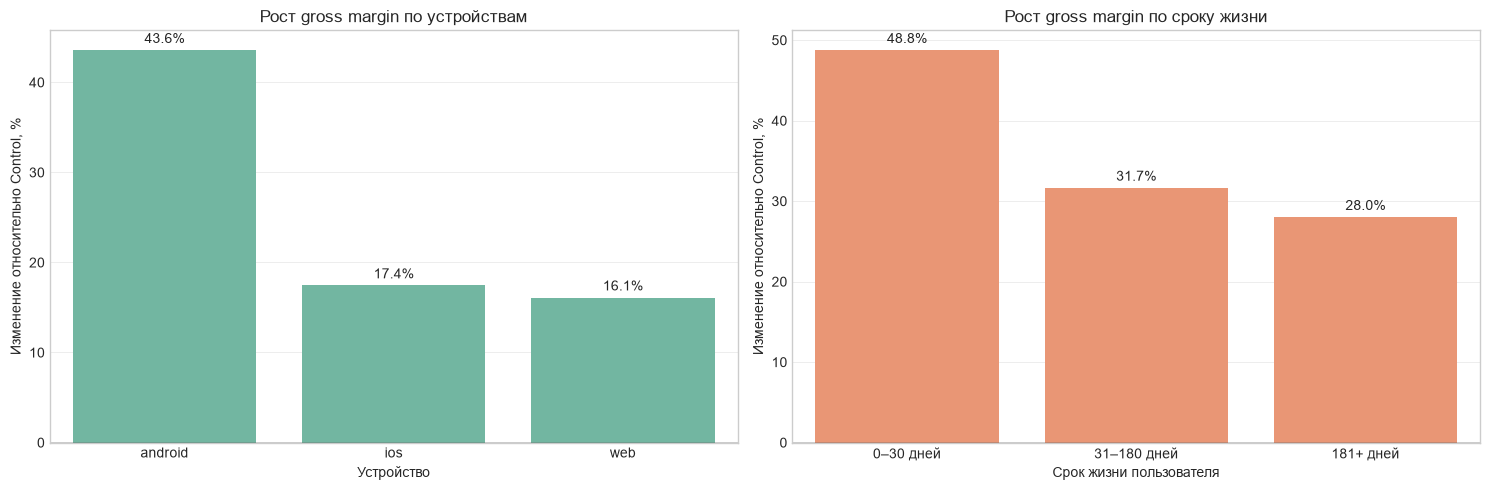

In [59]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5)
)

sns.barplot(
    data=device_results,
    x='segment',
    y='margin_uplift_pct',
    ax=axes[0],
    color='#66c2a5'
)

axes[0].axhline(
    0,
    color='black',
    linewidth=1
)

axes[0].set_title(
    'Рост gross margin по устройствам'
)
axes[0].set_xlabel('Устройство')
axes[0].set_ylabel('Изменение относительно Control, %')

for container in axes[0].containers:
    axes[0].bar_label(
        container,
        fmt='%.1f%%',
        padding=3
    )

sns.barplot(
    data=tenure_results,
    x='segment',
    y='margin_uplift_pct',
    ax=axes[1],
    color='#fc8d62'
)

axes[1].axhline(
    0,
    color='black',
    linewidth=1
)

axes[1].set_title(
    'Рост gross margin по сроку жизни'
)
axes[1].set_xlabel('Срок жизни пользователя')
axes[1].set_ylabel('Изменение относительно Control, %')

for container in axes[1].containers:
    axes[1].bar_label(
        container,
        fmt='%.1f%%',
        padding=3
    )

plt.tight_layout()
plt.show()

### 5.5 Итоговый вывод по сегментационному анализу

Новая рекомендательная модель показывает положительный эффект в большинстве рассмотренных сегментов, но величина эффекта и сопутствующие риски различаются.

Наиболее сильный пользовательский эффект наблюдается на Android и среди пользователей, зарегистрированных не более 30 дней назад. Android является крупнейшим и наиболее перспективным сегментом для первого этапа внедрения. Новые пользователи демонстрируют максимальный рост gross margin и конверсии, но одновременно имеют наибольший рост возвратов.

Среди товарных категорий наиболее благоприятное соотношение роста и риска наблюдается в Electronics, Pet и FMCG. Fashion и Sports создают дополнительную маржу, но сопровождаются существенным увеличением Return Rate.

Web является наименее убедительным пользовательским сегментом: наблюдаемый рост gross margin положительный, но статистически не подтверждён на уровне значимости 5%.

Сегментные результаты являются разведочными и не доказывают статистического различия эффектов между сегментами. Тем не менее они позволяют определить направления для поэтапного внедрения и усиленного мониторинга.

## 6. Бизнес-интерпретация результатов

Статистически значимый результат не всегда означает достаточную бизнес-ценность для масштабирования.

В этом разделе оцениваются:

- устойчивость эффекта во времени;
- ожидаемый эффект при масштабировании;
- компромисс между ростом продаж и ухудшением защитных метрик;
- ограничения 30-дневного эксперимента.

### 6.1 Устойчивость эффекта во времени

Проверим ежедневную динамику событийного CTR. Это позволит определить, сохранялось ли преимущество Test в течение всего эксперимента или было сосредоточено только в отдельных днях.

Дополнительно сравним среднюю разницу CTR в первые и последние 15 дней эксперимента.

In [60]:
# Преобразуем время показа в формат даты и времени
analysis_impressions['event_time'] = pd.to_datetime(
    analysis_impressions['event_time']
)

daily_ctr = (
    analysis_impressions
    .assign(
        date=lambda data:
        data['event_time'].dt.floor('D')
    )
    .merge(
        clean_assignments[
            ['user_id', 'experiment_group']
        ],
        on='user_id',
        how='inner',
        validate='many_to_one'
    )
    .groupby(
        ['date', 'experiment_group']
    )
    .agg(
        impressions=('impression_id', 'size'),
        clicks=('is_clicked', 'sum')
    )
    .reset_index()
)

daily_ctr['ctr_pct'] = (
    daily_ctr['clicks']
    / daily_ctr['impressions']
    * 100
)

display(daily_ctr.head())

,date,experiment_group,impressions,clicks,ctr_pct
0,2026-07-01,control,16910,1284,7.59
1,2026-07-01,test,17394,1544,8.88
2,2026-07-02,control,16753,1234,7.37
3,2026-07-02,test,17555,1572,8.95
4,2026-07-03,control,16780,1229,7.32


In [61]:
daily_ctr_wide = daily_ctr.pivot(
    index='date',
    columns='experiment_group',
    values='ctr_pct'
)

daily_ctr_wide['difference_pp'] = (
    daily_ctr_wide['test']
    - daily_ctr_wide['control']
)

daily_ctr_wide['period'] = np.where(
    daily_ctr_wide.index
    <= experiment_start + pd.Timedelta(days=14),

    'Первые 15 дней',
    'Последние 15 дней'
)

period_ctr_summary = (
    daily_ctr_wide
    .groupby('period')['difference_pp']
    .agg(
        mean_difference_pp='mean',
        minimum_difference_pp='min',
        maximum_difference_pp='max'
    )
    .round(2)
)

display(period_ctr_summary)

,mean_difference_pp,minimum_difference_pp,maximum_difference_pp
period,,,
Первые 15 дней,1.70,1.28,2.28
Последние 15 дней,1.74,1.13,2.37


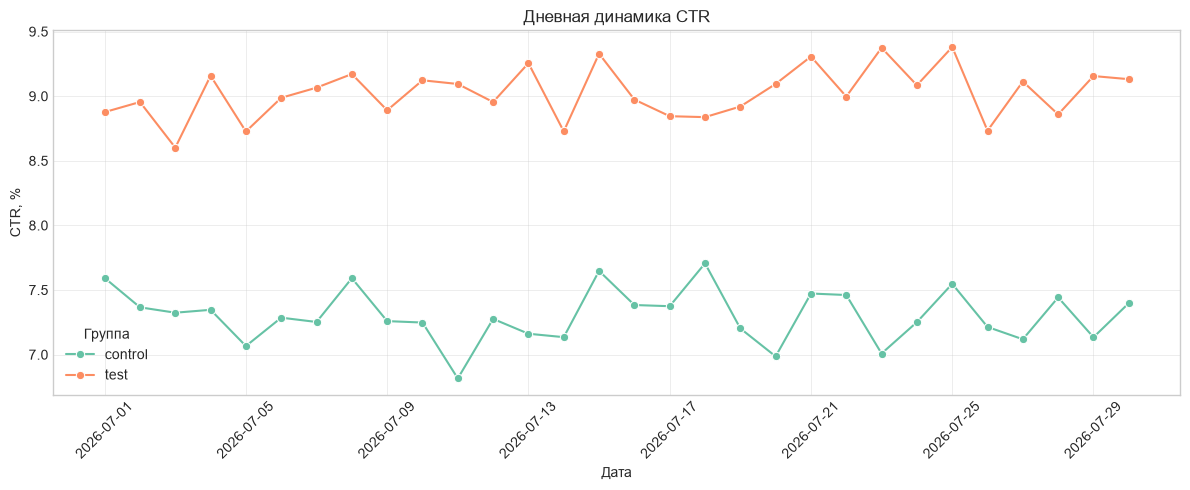

In [62]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=daily_ctr,
    x='date',
    y='ctr_pct',
    hue='experiment_group',
    marker='o'
)

plt.title('Дневная динамика CTR')
plt.xlabel('Дата')
plt.ylabel('CTR, %')
plt.legend(title='Группа')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Вывод по устойчивости эффекта

На протяжении всех 30 дней событийный CTR в Test оставался выше, чем в Control. Ежедневная разница находилась в диапазоне от +1,13 до +2,37 п.п.

В первые 15 дней средняя разница CTR составляла +1,70 п.п., а в последние 15 дней — +1,74 п.п. Следовательно, к концу эксперимента эффект не снижался.

Явных признаков краткосрочного эффекта новизны или затухания результата в пределах 30-дневного окна не обнаружено. При этом эксперимент не позволяет оценить устойчивость эффекта на более длительном горизонте.

### 6.2 Оценка эффекта при масштабировании

Для бизнес-интерпретации пересчитаем наблюдаемые 30-дневные эффекты на 100 тысяч пользователей.

Расчёт является линейной экстраполяцией результатов эксперимента. Он предполагает сохранение состава аудитории, поведения пользователей и качества работы модели при масштабировании.

Полученные значения не являются гарантированным прогнозом, поскольку полный запуск может сопровождаться изменением пользовательского поведения, товарного предложения и операционной нагрузки.

In [63]:
users_scale = 100_000

control_users_metrics = metric_users[
    metric_users['experiment_group'].eq('control')
]

test_users_metrics = metric_users[
    metric_users['experiment_group'].eq('test')
]

business_impact = pd.DataFrame({
    'indicator': [
        'Дополнительные покупатели',
        'Дополнительные заказы',
        'Дополнительный GMV, ₽',
        'Дополнительная gross margin, ₽',
        'Дополнительные повторные покупатели',
        'Дополнительные пользователи с возвратом',
        'Дополнительные пользователи с обращением в поддержку'
    ],

    'effect_per_100k': [
        (
            test_users_metrics['buyer'].mean()
            - control_users_metrics['buyer'].mean()
        ) * users_scale,

        (
            test_users_metrics['orders'].mean()
            - control_users_metrics['orders'].mean()
        ) * users_scale,

        (
            test_users_metrics['gmv_rub'].mean()
            - control_users_metrics['gmv_rub'].mean()
        ) * users_scale,

        (
            test_users_metrics['gross_margin_rub'].mean()
            - control_users_metrics['gross_margin_rub'].mean()
        ) * users_scale,

        (
            test_users_metrics['repeat_buyer'].mean()
            - control_users_metrics['repeat_buyer'].mean()
        ) * users_scale,

        (
            test_users_metrics['return_any'].mean()
            - control_users_metrics['return_any'].mean()
        ) * users_scale,

        (
            test_users_metrics['support_any'].mean()
            - control_users_metrics['support_any'].mean()
        ) * users_scale
    ]
})

business_impact['effect_per_100k'] = (
    business_impact['effect_per_100k'].round()
)

display(business_impact)

,indicator,effect_per_100k
0,Дополнительные покупатели,3368.00
1,Дополнительные заказы,4274.00
2,"Дополнительный GMV, ₽",7577525.00
3,"Дополнительная gross margin, ₽",1117517.00
4,Дополнительные повторные покупатели,798.00
5,Дополнительные пользователи с возвратом,453.00
6,Дополнительные пользователи с обращением в под...,274.00


In [64]:
control_premium_eligible = premium_eligible[
    premium_eligible['experiment_group'].eq('control')
]

test_premium_eligible = premium_eligible[
    premium_eligible['experiment_group'].eq('test')
]

premium_effect_per_100k_eligible = (
    test_premium_eligible['new_premium'].mean()
    - control_premium_eligible['new_premium'].mean()
) * 100_000

print(
    'Дополнительных Premium-конверсий '
    'на 100 000 пользователей без Premium на старте:',
    round(premium_effect_per_100k_eligible)
)

Дополнительных Premium-конверсий на 100 000 пользователей без Premium на старте: 546


#### Вывод по эффекту масштабирования

При линейном переносе результатов эксперимента на 100 тысяч пользователей новая модель может обеспечить приблизительно 3 368 дополнительных покупателей, 4 274 дополнительных заказа, 7,58 млн ₽ дополнительного GMV и 1,12 млн ₽ дополнительной gross margin за 30 дней.

Кроме того, ожидается около 798 дополнительных повторных покупателей. Среди 100 тысяч пользователей без Premium на начало периода модель может обеспечить приблизительно 546 дополнительных Premium-конверсий.

Одновременно масштабирование может привести примерно к 453 дополнительным пользователям с возвратом и 274 дополнительным пользователям с обращением в поддержку.

Таким образом, наблюдаемый коммерческий эффект существенно положительный, но сопровождается ростом нагрузки на процессы возвратов и поддержки. Рассчитанная gross margin не является чистой прибылью и не учитывает все возможные операционные затраты масштабирования.

Оценка является линейной экстраполяцией 30-дневного эксперимента, а не гарантированным прогнозом.

### 6.3 Влияние на службу поддержки

Доля пользователей с обращением в поддержку статистически значимо выросла в Test. Для бизнес-интерпретации дополнительно изучим причины обращений, среднюю тональность сообщений и долю обращений, решённых в течение 24 часов.

Анализ обращений является описательным и помогает определить возможные источники ухудшения пользовательского опыта.

In [65]:
support_with_group = (
    analysis_support
    .merge(
        clean_assignments[
            ['user_id', 'experiment_group']
        ],
        on='user_id',
        how='inner',
        validate='many_to_one'
    )
)

support_summary = (
    support_with_group
    .groupby('experiment_group')
    .agg(
        tickets=('ticket_id', 'nunique'),
        users_with_tickets=('user_id', 'nunique'),
        mean_sentiment=(
            'sentiment_score',
            'mean'
        ),
        resolved_within_24h_pct=(
            'resolved_within_24h',
            lambda values: values.mean() * 100
        )
    )
    .round(2)
)

display(support_summary)

,tickets,users_with_tickets,mean_sentiment,resolved_within_24h_pct
experiment_group,,,,
control,132,131,0.07,72.73
test,201,201,0.07,71.64


In [66]:
support_reasons = (
    support_with_group
    .groupby(
        ['reason', 'experiment_group']
    )
    ['ticket_id']
    .nunique()
    .unstack(
        fill_value=0
    )
)

support_reason_rate = (
    support_reasons
    .div(group_sizes, axis='columns')
    * 10_000
)

support_reason_rate['difference_per_10k'] = (
    support_reason_rate['test']
    - support_reason_rate['control']
)

support_reason_rate = (
    support_reason_rate
    .sort_values(
        'difference_per_10k',
        ascending=False
    )
)

support_reason_rate.style.format({
    'control': '{:.2f}',
    'test': '{:.2f}',
    'difference_per_10k': '{:+.2f}'
})

experiment_group,control,test,difference_per_10k
reason,,,
product_quality,18.39,27.79,+9.40
return_request,6.13,14.10,+7.97
payment_issue,4.49,8.86,+4.37
delivery_delay,13.89,16.92,+3.02
wrong_item,6.13,8.86,+2.73
recommendation_quality,4.90,4.43,-0.47


Поскольку Test создал больше заказов, рост обращений на пользователя может частично объясняться увеличением объёма покупок. Для разделения эффекта объёма и качества дополнительно рассчитаем количество обращений каждой причины на 1 000 заказов.

In [67]:
order_counts_by_group = (
    orders_economics['orders']
)

support_reason_per_1000_orders = (
    support_reasons
    .div(
        order_counts_by_group,
        axis='columns'
    )
    * 1_000
)

support_reason_per_1000_orders[
    'difference_per_1000_orders'
] = (
    support_reason_per_1000_orders['test']
    - support_reason_per_1000_orders['control']
)

support_reason_per_1000_orders = (
    support_reason_per_1000_orders
    .sort_values(
        'difference_per_1000_orders',
        ascending=False
    )
)

support_reason_per_1000_orders.style.format({
    'control': '{:.2f}',
    'test': '{:.2f}',
    'difference_per_1000_orders': '{:+.2f}'
})

experiment_group,control,test,difference_per_1000_orders
reason,,,
return_request,4.84,8.33,+3.48
product_quality,14.53,16.41,+1.89
payment_issue,3.55,5.23,+1.68
wrong_item,4.84,5.23,+0.39
delivery_delay,10.97,9.99,-0.98
recommendation_quality,3.87,2.62,-1.26


#### Вывод по обращениям в поддержку

В Test количество обращений увеличилось со 132 до 201. Средняя тональность обращений практически не изменилась, а доля обращений, решённых за 24 часа, снизилась незначительно — с 72,73% до 71,64%. На масштабе эксперимента признаков критической перегрузки поддержки не обнаружено.

После нормализации на количество заказов основной рост наблюдается по запросам на возврат: 8,33 против 4,84 обращения на 1 000 заказов. Также увеличилось количество обращений по качеству товара и проблемам с оплатой.

Одновременно количество обращений по задержкам доставки и качеству рекомендаций на 1 000 заказов снизилось. Следовательно, пользователи не стали чаще жаловаться непосредственно на рекомендации. Основные риски возникают после совершения покупки и связаны с возвратами, качеством выбранных товаров и платёжным процессом.

Рост проблем с качеством товара нельзя однозначно считать прямым следствием модели. Новая система могла изменить структуру покупаемых категорий, товаров и продавцов. Для установления причины необходим дополнительный анализ товарного ассортимента и продавцов.

### 6.4 Ограничения исследования
При интерпретации результатов необходимо учитывать следующие ограничения:

1. Эксперимент продолжался только 30 дней. Этого достаточно для оценки краткосрочных кликов, заказов и маржи, но недостаточно для полноценной оценки удержания и LTV.

2. 65% известных возвратов произошли после окончания экспериментального окна. Использование всех доступных возвратов уменьшает недооценку Return Rate, но длительность наблюдения за заказами различается в зависимости от даты покупки.

3. Поле `gross_margin_rub` используется в готовом виде. Формула его расчёта неизвестна, а данные не содержат полного состава операционных затрат, стоимости поддержки и обработки возвратов. Поэтому gross margin нельзя интерпретировать как чистую прибыль.

4. Из строгой событийной цепочки исключены заказы, связанные с показами, отмеченными как дублирующиеся события. Это обеспечивает согласованность воронки, но делает результат зависимым от выбранного подхода к очистке.

5. Сегментационный анализ является разведочным. Различия наблюдаемых эффектов между сегментами не подтверждены отдельными тестами статистического взаимодействия.

6. Категория покупки является постэкспериментальной характеристикой и могла быть изменена самой рекомендательной моделью. Поэтому категорийный анализ используется для бизнес-интерпретации, а не как отдельный рандомизированный эксперимент.

7. Линейная экстраполяция на 100 тысяч пользователей предполагает сохранение состава аудитории и эффекта модели. При полном запуске результат может измениться из-за масштабирования нагрузки, изменения ассортимента и поведения пользователей.

8. Стабильность CTR подтверждена только в пределах 30 дней. Для оценки долгосрочного эффекта необходим более длительный горизонт наблюдения.

## 7. Рекомендации руководству

### 7.1 Решение о внедрении

Рекомендуется продолжить внедрение новой рекомендательной модели, но отказаться от одномоментного запуска на 100% аудитории.

Эксперимент показывает статистически значимый положительный эффект:

- конверсия пользователя в покупателя выросла на 3,37 п.п.;
- количество заказов на пользователя увеличилось на 33,76%;
- GMV на пользователя вырос на 75,78 ₽, или на 36,12%;
- gross margin на пользователя выросла на 11,18 ₽, или на 31,96%;
- увеличились повторные покупки и Premium Conversion;
- эффект CTR сохранялся на протяжении всего 30-дневного периода.

При этом модель ухудшает защитные и удельные показатели:

- доля пользователей с возвратом выросла на 0,45 п.п.;
- order-level Return Rate увеличился с 5,55% до 6,85%;
- доля пользователей с обращением в поддержку выросла на 0,27 п.п.;
- gross margin на заказ снизилась приблизительно с 276 до 272 ₽;
- gross margin rate снизилась с 16,66% до 16,16%.

Таким образом, положительный краткосрочный бизнес-эффект подтверждён, но модель требует контролируемого поэтапного внедрения.

### 7.2 Предлагаемый план поэтапного внедрения

#### Этап 1. Ограниченный запуск

Начать внедрение с наиболее перспективных и относительно безопасных сегментов:

- пользователи Android;
- категории Electronics, Pet и FMCG;
- ограниченная доля аудитории с сохранением контрольной группы.

Первую волну целесообразно сосредоточить на Android. Если архитектура модели позволяет управлять рекомендациями на уровне товарных категорий, приоритет можно отдать Electronics, Pet и FMCG, одновременно ограничив и отдельно контролируя Fashion и Sports.
На этом этапе рекомендуется сохранить постоянную контрольную группу в размере 5–10%, чтобы отслеживать изменение эффекта после масштабирования.

#### Этап 2. Расширение аудитории

При сохранении положительной gross margin на пользователя и допустимого уровня защитных метрик расширить внедрение:

- на пользователей iOS;
- на пользователей среднего и большого срока жизни;
- на дополнительные товарные категории с умеренным риском.

#### Этап 3. Работа с рискованными сегментами

Fashion и Sports не рекомендуется включать в первую волну полного масштабирования. В этих категориях рост gross margin сопровождается увеличением Return Rate на 3,87 и 3,39 п.п.

Перед расширением необходимо определить:

- товары и продавцов, создающих возвраты;
- причины возвратов;
- связь возвратов со скидками, качеством товара и точностью рекомендаций;
- возможность снизить вес рискованных товаров в алгоритме.

Новые пользователи также требуют отдельного мониторинга. Они демонстрируют максимальный коммерческий эффект, но одновременно максимальный рост доли пользователей с возвратом.

Web не является приоритетным сегментом для первой волны, поскольку наблюдаемый рост gross margin статистически не подтверждён на уровне значимости 5%.

### 7.3 Метрики контроля при внедрении

В процессе rollout необходимо ежедневно или еженедельно контролировать:

#### Основные метрики ценности

- конверсию пользователя в покупателя;
- количество заказов на пользователя;
- GMV на пользователя;
- gross margin на пользователя;
- Premium Conversion;
- повторные покупки.

#### Защитные метрики

- Return Rate на уровне заказов;
- долю пользователей с возвратом;
- обращения в поддержку на пользователя и на заказ;
- обращения по причинам `return_request`, `product_quality` и `payment_issue`;
- gross margin на заказ;
- gross margin rate;
- долю обращений, решённых за 24 часа.

#### Разрезы мониторинга

Метрики необходимо контролировать отдельно:

- по устройствам;
- по сроку жизни пользователя;
- по товарным категориям;
- по товарам и продавцам;
- по дате заказа и дате возврата.

Масштабирование следует приостановить, если положительный эффект gross margin на пользователя исчезает либо рост возвратов и обращений в поддержку превышает согласованный с бизнесом допустимый уровень.

Конкретные пороговые значения guardrail-метрик должны быть установлены совместно с продуктовыми, финансовыми, логистическими и операционными командами с учётом реальной стоимости возврата и обработки обращения.

### 7.4 Основные риски внедрения

1. **Рост возвратов.** Увеличение Return Rate может частично компенсировать дополнительную маржу и повысить затраты на обратную логистику.

2. **Рост нагрузки на поддержку.** На 100 тысяч пользователей ожидается приблизительно 274 дополнительных пользователя с обращением. Основной прирост связан с возвратами, качеством товара и оплатой.

3. **Ухудшение удельной экономики.** Несмотря на рост общей gross margin, gross margin на один заказ и gross margin rate немного снижаются.

4. **Риск товарного состава.** Модель может чаще продвигать категории, товары или продавцов с высокой вероятностью возврата.

5. **Риск масштабирования.** Эффект, полученный на экспериментальной выборке, может измениться при запуске на всю аудиторию.

6. **Недостаточный горизонт.** Тридцатидневный период не позволяет оценить долгосрочное удержание, LTV и устойчивость эффекта на горизонте нескольких месяцев.

7. **Неполная экономика.** В датасете отсутствует полная стоимость поддержки, логистики, возвратов и эксплуатации модели.

## 8. Дополнительные данные перед окончательным решением

Перед окончательным полномасштабным запуском у продуктовой команды необходимо запросить следующие данные.

### 8.1 Полная экономика заказа

- формула расчёта `gross_margin_rub`;
- стоимость прямой и обратной логистики;
- стоимость обработки возврата;
- стоимость одного обращения в поддержку;
- комиссии и платёжные расходы;
- инфраструктурная стоимость работы новой модели;
- дополнительные маркетинговые или скидочные расходы.

Эти данные позволят перейти от gross margin к оценке реального инкрементального финансового эффекта.

### 8.2 Детализация возвратов

- причина возврата;
- дата получения товара;
- дата подачи заявки на возврат;
- состояние возвращённого товара;
- стоимость обратной логистики;
- категория, товар и продавец;
- был ли возврат полным или частичным.

Это позволит определить, связаны ли возвраты с нерелевантными рекомендациями, качеством товара, продавцом, доставкой или другими причинами.

### 8.3 Данные о товарах и продавцах

- остатки и доступность товара;
- динамика цены;
- размер скидки;
- рейтинг и история продавца;
- фактические сроки доставки;
- доля возвратов товара до эксперимента;
- количество жалоб и отмен;
- позиция товара в рекомендательной выдаче.

Эти данные помогут ограничить продвижение товаров и продавцов с высоким риском возврата.

### 8.4 Долгосрочные пользовательские показатели

- активность через 60 и 90 дней;
- удержание пользователей;
- повторные покупки на более длинном горизонте;
- накопленный GMV и gross margin;
- продление и отмена Premium;
- долгосрочная частота возвратов;
- LTV пользователей.

Тридцатидневные GMV и gross margin на пользователя являются только краткосрочными прокси ценности и не заменяют полноценный LTV.

### 8.5 Технические данные рекомендательной системы

- версия модели;
- скор и позиция каждой рекомендации;
- источник кандидата товара;
- признаки, использованные моделью;
- время ответа модели;
- ошибки и недоступность сервиса;
- доля пользователей, фактически получивших новую выдачу;
- история изменения модели во время эксперимента.

Эти данные необходимы для проверки корректности воздействия и поиска причин сегментных различий.

### 8.6 Данные о платёжном пути и поддержке

- тип и код ошибки оплаты;
- платёжный провайдер;
- этап возникновения ошибки;
- повторная успешная оплата;
- время до первого ответа поддержки;
- полное время решения обращения;
- повторные обращения по одной проблеме;
- операционная стоимость обращения.

Это позволит понять причины роста `payment_issue` и оценить способность операционных команд выдержать масштабирование.

## Итог

Новая рекомендательная модель доказала способность существенно увеличивать клики, покупки, GMV, gross margin, повторные покупки и Premium Conversion. Положительный эффект статистически значим, сохраняется на протяжении 30 дней и имеет практический бизнес-масштаб.

Одновременно модель повышает Return Rate и нагрузку на поддержку, а удельная маржинальность заказа немного снижается. Поэтому рекомендуется не отклонять модель и не запускать её одномоментно на всю аудиторию, а провести контролируемое поэтапное внедрение.

Первую волну целесообразно сосредоточить на Android и категориях Electronics, Pet и FMCG с сохранением постоянной контрольной группы и мониторингом возвратов, поддержки и маржинальности. Fashion, Sports, новых пользователей и Web следует масштабировать отдельно после дополнительного анализа рисков.

Окончательное решение о полном запуске необходимо принимать после получения более длительных данных и расчёта полной экономики возвратов, поддержки, логистики и эксплуатации модели.